In [1]:
getwd()

[1] "/fast/AG_Bunina/Yusuf/Project_Endothelial_and_Stroke/Datasets/Chromatin_and_Gene_Exp/2024_C_A_Mannens_C_et_al/04_02_25"

In [2]:
here::here()

[1] "/fast/AG_Bunina/Yusuf/Project_Endothelial_and_Stroke/Datasets/Chromatin_and_Gene_Exp/2024_C_A_Mannens_C_et_al/04_02_25"

In [3]:
# load the R environment with the necessary packages such as Epiregulon:

my_epiregulon_lib <- here::here("renv", "library/linux-rhel-9.4/R-4.4/x86_64-unknown-linux-gnu")

In [4]:
.libPaths(new = my_epiregulon_lib, include.site = FALSE)

In [5]:
.libPaths()

[1] "/fast/AG_Bunina/Yusuf/Project_Endothelial_and_Stroke/Datasets/Chromatin_and_Gene_Exp/2024_C_A_Mannens_C_et_al/04_02_25/renv/library/linux-rhel-9.4/R-4.4/x86_64-unknown-linux-gnu"
[2] "/gnu/store/29x2k7i71g9xq09xmbj1lk515cl7if63-r-minimal-4.4.2/lib/R/library"

In [6]:
library(SingleCellExperiment)

Loading required package: SummarizedExperiment

Loading required package: MatrixGenerics

Loading required package: matrixStats


Attaching package: 'MatrixGenerics'


The following objects are masked from 'package:matrixStats':

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantiles, colRanges, colRanks, colSdDiffs, colSds,
    colSums2, colTabulates, colVarDiffs, colVars, colWeightedMads,
    colWeightedMeans, colWeightedMedians, colWeightedSds,
    colWeightedVars, rowAlls, rowAnyNAs, rowAnys, rowAvgsPerColSet,
    rowCollapse, rowCounts, rowCummaxs, rowCummins, rowCumprods,
    rowCumsums, rowDiffs, rowIQRDiffs, rowIQRs, rowLogSumExps,
    rowMadDiffs, rowMads, rowMaxs, rowMeans2, rowMedians, rowMins,
    rowOrderStats, rowProds, rowQuantiles, rowRanges

In [7]:
GeneExpressionMatrix <- readRDS(here::here('r_objects', 'sce_rna_mannens.RDS'))

In [8]:
PeakMatrix <- readRDS(here::here('r_objects', 'sce_atac_mannens.RDS'))

In [9]:
GeneExpressionMatrix

class: SingleCellExperiment 
dim: 20667 49470 
metadata(0):
assays(3): counts logcounts scaledata
rownames(20667): ENSG00000279457 ENSG00000237491 ... ENSG00000188120
  ENSG00000205944
rowData names(2): gene_id gene_name
colnames(49470): 10X280_1:CAGATTCAGCAGCTCA 10X365_2:ACCAATATCAATGACC
  ... 10X346_4:CGCTGTGCACGTAATT 10X406_4:GAGAAACGTGGTGAGA
colData names(91): orig.ident nCount_RNA ... peaks.weight ident
reducedDimNames(3): PCA UMAP_RNA JOINT_UMAP
mainExpName: RNA
altExpNames(0):

In [10]:
PeakMatrix

class: SingleCellExperiment 
dim: 405121 49470 
metadata(0):
assays(2): counts logcounts
rownames: NULL
rowData names(0):
colnames(49470): 10X280_1:CAGATTCAGCAGCTCA 10X365_2:ACCAATATCAATGACC
  ... 10X346_4:CGCTGTGCACGTAATT 10X406_4:GAGAAACGTGGTGAGA
colData names(91): orig.ident nCount_RNA ... peaks.weight ident
reducedDimNames(2): PCA_ATAC UMAP_ATAC
mainExpName: NULL
altExpNames(0):

In [11]:
# Before running epiregulon functions, it is important to make sure the genome info
# between the gene and peak features and the motif features that will be used are
# consistent. Seqnames (chr number formatting) etc. should be concordant between
# rowranges of genes and rowranges of peaks and the granges of TF motifs.

# I will adapt each objects' those relevant attributes for consistency before
# any progress in the pipeline.

# NOTE: My human genome version in the Mannens et al. data is hg38.

In [12]:
# Retrieve TF motifs available in epiregulon package:

grl <- epiregulon::getTFMotifInfo(genome = "hg38")

see ?scMultiome and browseVignettes('scMultiome') for documentation

loading from cache



In [13]:
grl

GRangesList object of length 1558:
$AEBP2
GRanges object with 2700 ranges and 0 metadata columns:
         seqnames            ranges strand
            <Rle>         <IRanges>  <Rle>
     [1]     chr1        9792-10446      *
     [2]     chr1     942105-942400      *
     [3]     chr1     984486-984781      *
     [4]     chr1   3068932-3069282      *
     [5]     chr1   3069411-3069950      *
     ...      ...               ...    ...
  [2696]     chrY   8465261-8465730      *
  [2697]     chrY 11721744-11722260      *
  [2698]     chrY 11747448-11747964      *
  [2699]     chrY 19302661-19303134      *
  [2700]     chrY 19985662-19985982      *
  -------
  seqinfo: 25 sequences from an unspecified genome; no seqlengths

...
<1557 more elements>

In [14]:
GeneExpressionMatrix@assays@data$counts |> head()

  [[ suppressing 34 column names '10X280_1:CAGATTCAGCAGCTCA', '10X365_2:ACCAATATCAATGACC', '10X365_2:ATGGTGCGTCACCTAT' ... ]]



6 x 49470 sparse Matrix of class "dgCMatrix"
                                                                             
WASH9P    . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . .
LINC01409 . . . . . . . . . . . . . . . . . . 1 . . . . . . . . . . . . . . .
FAM87B    . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . .
FAM41C    . . . . . . . . . . . . . . . . . . 1 . . . . . . . . . . . . . . .
LINC02593 . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . .
SAMD11    . . . . . . . . . . . . . . . . . . 1 . . . . . . . . . . . . . . .
                
WASH9P    ......
LINC01409 ......
FAM87B    ......
FAM41C    ......
LINC02593 ......
SAMD11    ......

 .....suppressing 49436 columns in show(); maybe adjust options(max.print=, width=)
 ..............................

In [15]:
GeneExpressionMatrix@assays@data$logcounts |> head()

  [[ suppressing 34 column names '10X280_1:CAGATTCAGCAGCTCA', '10X365_2:ACCAATATCAATGACC', '10X365_2:ATGGTGCGTCACCTAT' ... ]]



6 x 49470 sparse Matrix of class "dgCMatrix"
                                                                              
WASH9P    . . . . . . . . . . . . . . . . . . .        . . . . . . . . . . . .
LINC01409 . . . . . . . . . . . . . . . . . . 1.172991 . . . . . . . . . . . .
FAM87B    . . . . . . . . . . . . . . . . . . .        . . . . . . . . . . . .
FAM41C    . . . . . . . . . . . . . . . . . . 1.172991 . . . . . . . . . . . .
LINC02593 . . . . . . . . . . . . . . . . . . .        . . . . . . . . . . . .
SAMD11    . . . . . . . . . . . . . . . . . . 1.172991 . . . . . . . . . . . .
                      
WASH9P    . . . ......
LINC01409 . . . ......
FAM87B    . . . ......
FAM41C    . . . ......
LINC02593 . . . ......
SAMD11    . . . ......

 .....suppressing 49436 columns in show(); maybe adjust options(max.print=, width=)
 ..............................

In [16]:
GeneExpressionMatrix@assays@data$scaledata |> dim()

[1] 20667 49470

In [17]:
GeneExpressionMatrix@assays@data$scaledata |> class()

[1] "matrix" "array"

In [18]:
# Seurat stores the scaled counts as dense matrices, so it is not dgCMatrix of class.

In [19]:
PeakMatrix@assays@data$counts |> head()

  [[ suppressing 34 column names '10X280_1:CAGATTCAGCAGCTCA', '10X365_2:ACCAATATCAATGACC', '10X365_2:ATGGTGCGTCACCTAT' ... ]]



6 x 49470 sparse Matrix of class "dgCMatrix"
                                                                               
chr10-100006329-100006730 . . . . . . . . . . . . . . . . . . . . . . . . . . .
chr10-100009751-100010152 . . . . . . . . 1 . . . . . 1 1 . . 1 1 . . . . 1 . .
chr10-100016741-100017142 . . . . . . . . . . . . . . . . . . . . . . . . . . .
chr10-100019766-100020167 . . . . . . . . . . . . . . . . . . . . . . . . . . .
chr10-100020276-100020677 . . . . . . . . . . . . . . . . . . . . . . . . . . .
chr10-100020877-100021278 . . . . . . . . . . . . . . . . . . . . 2 . . . . . .
                                              
chr10-100006329-100006730 . . . . . . . ......
chr10-100009751-100010152 . . 1 . . . . ......
chr10-100016741-100017142 . . . . . . . ......
chr10-100019766-100020167 . . . . . . . ......
chr10-100020276-100020677 . . . . . . . ......
chr10-100020877-100021278 . . . . . . . ......

 .....suppressing 49436 columns in show(); maybe adjust options(m

In [20]:
PeakMatrix@assays@data$logcounts |> head()

  [[ suppressing 34 column names '10X280_1:CAGATTCAGCAGCTCA', '10X365_2:ACCAATATCAATGACC', '10X365_2:ATGGTGCGTCACCTAT' ... ]]



6 x 49470 sparse Matrix of class "dgCMatrix"
                                                                      
chr10-100006329-100006730 . . . . . . . . .         . . . . . .       
chr10-100009751-100010152 . . . . . . . . 0.8201684 . . . . . 1.070958
chr10-100016741-100017142 . . . . . . . . .         . . . . . .       
chr10-100019766-100020167 . . . . . . . . .         . . . . . .       
chr10-100020276-100020677 . . . . . . . . .         . . . . . .       
chr10-100020877-100021278 . . . . . . . . .         . . . . . .       
                                                                         
chr10-100006329-100006730 .         . . .         .        .        . . .
chr10-100009751-100010152 0.7369955 . . 0.7147449 1.023804 .        . . .
chr10-100016741-100017142 .         . . .         .        .        . . .
chr10-100019766-100020167 .         . . .         .        .        . . .
chr10-100020276-100020677 .         . . .         .        .        . . .
chr10-10002087

In [22]:
# I verified above that the counts and logcounts assays 
# are stored in dgCMatrix, as required by epiregulon.

In [23]:
width(PeakMatrix) |> head()

[1] 402 402 402 402 402 402

In [24]:
width(GeneExpressionMatrix) |> head()

[1] 10195 31319  2467  8833  4152 20653

In [25]:
genome(PeakMatrix)

chr10 chr11 chr12 chr13 chr14 chr15 chr16 chr17 chr18 chr19  chr1 chr20 chr21 
   NA    NA    NA    NA    NA    NA    NA    NA    NA    NA    NA    NA    NA 
chr22  chr2  chr3  chr4  chr5  chr6  chr7  chr8  chr9  chrX  chrY 
   NA    NA    NA    NA    NA    NA    NA    NA    NA    NA    NA

In [26]:
genome(GeneExpressionMatrix)

1                                     10 
                              "GRCh38"                               "GRCh38" 
                                    11                                     12 
                              "GRCh38"                               "GRCh38" 
                                    13                                     14 
                              "GRCh38"                               "GRCh38" 
                                    15                                     16 
                              "GRCh38"                               "GRCh38" 
                                    17                                     18 
                              "GRCh38"                               "GRCh38" 
                                    19                                      2 
                              "GRCh38"                               "GRCh38" 
                                    20                                     21 
                              "GRCh38"                               "GRCh38" 
                                    22                                      3 
                              "GRCh38"                               "GRCh38" 
                                     4                                      5 
                              "GRCh38"                               "GRCh38" 
                                     6                                      7 
                              "GRCh38"                               "GRCh38" 
                                     8                                      9 
                              "GRCh38"                               "GRCh38" 
                       CHR_HG107_PATCH                        CHR_HG109_PATCH 
                              "GRCh38"                               "GRCh38" 
                       CHR_HG126_PATCH                       CHR_HG1277_PATCH 
                              "GRCh38"                               "GRCh38" 
                      CHR_HG1298_PATCH                       CHR_HG1309_PATCH 
                              "GRCh38"                               "GRCh38" 
                      CHR_HG1311_PATCH                       CHR_HG1320_PATCH 
                              "GRCh38"                               "GRCh38" 
               CHR_HG1342_HG2282_PATCH                       CHR_HG1362_PATCH 
                              "GRCh38"                               "GRCh38" 
                      CHR_HG1384_PATCH                       CHR_HG1395_PATCH 
                              "GRCh38"                               "GRCh38" 
                      CHR_HG1398_PATCH             CHR_HG142_HG150_NOVEL_TEST 
                              "GRCh38"                               "GRCh38" 
                      CHR_HG1445_PATCH                       CHR_HG1485_PATCH 
                              "GRCh38"                               "GRCh38" 
                  CHR_HG151_NOVEL_TEST                       CHR_HG1524_PATCH 
                              "GRCh38"                               "GRCh38" 
                      CHR_HG1531_PATCH                       CHR_HG1535_PATCH 
                              "GRCh38"                               "GRCh38" 
                      CHR_HG1651_PATCH                       CHR_HG1708_PATCH 
                              "GRCh38"                               "GRCh38" 
                      CHR_HG1815_PATCH                       CHR_HG1832_PATCH 
                              "GRCh38"                               "GRCh38" 
                         CHR_HG1_PATCH                       CHR_HG2002_PATCH 
                              "GRCh38"                               "GRCh38" 
                      CHR_HG2021_PATCH                       CHR_HG2022_PATCH 
                              "GRCh38"                               "GRCh38" 
                      CHR_HG2023_PATCH                       CHR_HG2030_PATCH 
        

=====================================================================

My genome() output lists all chromosomes from GRCh38, including:

Primary assembly chromosomes (1-22, X, Y, MT)\
Fix patches\
Alternative haplotype sequences\
Highly variable loci (e.g., KIR, LRC regions)

In [27]:
# GRCh38 is synonym of hg38.

In [28]:
seqlevels(PeakMatrix)

[1] "chr10" "chr11" "chr12" "chr13" "chr14" "chr15" "chr16" "chr17" "chr18"
[10] "chr19" "chr1"  "chr20" "chr21" "chr22" "chr2"  "chr3"  "chr4"  "chr5" 
[19] "chr6"  "chr7"  "chr8"  "chr9"  "chrX"  "chrY"

In [29]:
seqlevels(GeneExpressionMatrix)

[1] "1"                                     
  [2] "10"                                    
  [3] "11"                                    
  [4] "12"                                    
  [5] "13"                                    
  [6] "14"                                    
  [7] "15"                                    
  [8] "16"                                    
  [9] "17"                                    
 [10] "18"                                    
 [11] "19"                                    
 [12] "2"                                     
 [13] "20"                                    
 [14] "21"                                    
 [15] "22"                                    
 [16] "3"                                     
 [17] "4"                                     
 [18] "5"                                     
 [19] "6"                                     
 [20] "7"                                     
 [21] "8"                                     
 [22] "9"                                     
 [23] "CHR_HG107_PATCH"                       
 [24] "CHR_HG109_PATCH"                       
 [25] "CHR_HG126_PATCH"                       
 [26] "CHR_HG1277_PATCH"                      
 [27] "CHR_HG1298_PATCH"                      
 [28] "CHR_HG1309_PATCH"                      
 [29] "CHR_HG1311_PATCH"                      
 [30] "CHR_HG1320_PATCH"                      
 [31] "CHR_HG1342_HG2282_PATCH"               
 [32] "CHR_HG1362_PATCH"                      
 [33] "CHR_HG1384_PATCH"                      
 [34] "CHR_HG1395_PATCH"                      
 [35] "CHR_HG1398_PATCH"                      
 [36] "CHR_HG142_HG150_NOVEL_TEST"            
 [37] "CHR_HG1445_PATCH"                      
 [38] "CHR_HG1485_PATCH"                      
 [39] "CHR_HG151_NOVEL_TEST"                  
 [40] "CHR_HG1524_PATCH"                      
 [41] "CHR_HG1531_PATCH"                      
 [42] "CHR_HG1535_PATCH"                      
 [43] "CHR_HG1651_PATCH"                      
 [44] "CHR_HG1708_PATCH"                      
 [45] "CHR_HG1815_PATCH"                      
 [46] "CHR_HG1832_PATCH"                      
 [47] "CHR_HG1_PATCH"                         
 [48] "CHR_HG2002_PATCH"                      
 [49] "CHR_HG2021_PATCH"                      
 [50] "CHR_HG2022_PATCH"                      
 [51] "CHR_HG2023_PATCH"                      
 [52] "CHR_HG2030_PATCH"                      
 [53] "CHR_HG2046_PATCH"                      
 [54] "CHR_HG2047_PATCH"                      
 [55] "CHR_HG2057_PATCH"                      
 [56] "CHR_HG2058_PATCH"                      
 [57] "CHR_HG2060_PATCH"                      
 [58] "CHR_HG2062_PATCH"                      
 [59] "CHR_HG2063_PATCH"                      
 [60] "CHR_HG2066_PATCH"                      
 [61] "CHR_HG2067_PATCH"                      
 [62] "CHR_HG2072_PATCH"                      
 [63] "CHR_HG2087_PATCH"                      
 [64] "CHR_HG2088_PATCH"                      
 [65] "CHR_HG2095_PATCH"                      
 [66] "CHR_HG2104_PATCH"                      
 [67] "CHR_HG2111_PATCH"                      
 [68] "CHR_HG2114_PATCH"                      
 [69] "CHR_HG2115_PATCH"                      
 [70] "CHR_HG2116_PATCH"                      
 [71] "CHR_HG2121_PATCH"                      
 [72] "CHR_HG2128_PATCH"                      
 [73] "CHR_HG2133_PATCH"                      
 [74] "CHR_HG2191_PATCH"                      
 [75] "CHR_HG2198_PATCH"                      
 [76] "CHR_HG2213_PATCH"                      
 [77] "CHR_HG2217_PATCH"                      
 [78] "CHR_HG2232_PATCH"                      
 [79] "CHR_HG2233_PATCH"                      
 [80] "CHR_HG2235_PATCH"                      
 [81] "CHR_HG2236_PATCH"                      
 [82] "CHR_HG2239_PATCH"                      
 [83] "CHR_HG2246_HG2248_HG2276_PATCH"        
 [84] "CHR_HG2247_PATCH"                      
 [85] "CHR_HG2249_PATCH"                      
 [86] "

In [30]:
genome(grl)

chr1  chr2  chr3  chr4  chr5  chr6  chr7  chr8  chr9 chr10 chr11 chr12 chr13 
   NA    NA    NA    NA    NA    NA    NA    NA    NA    NA    NA    NA    NA 
chr14 chr15 chr16 chr17 chr18 chr19 chr20 chr21 chr22  chrX  chrY  chrM 
   NA    NA    NA    NA    NA    NA    NA    NA    NA    NA    NA    NA

In [31]:
seqlevels(grl)

[1] "chr1"  "chr2"  "chr3"  "chr4"  "chr5"  "chr6"  "chr7"  "chr8"  "chr9" 
[10] "chr10" "chr11" "chr12" "chr13" "chr14" "chr15" "chr16" "chr17" "chr18"
[19] "chr19" "chr20" "chr21" "chr22" "chrX"  "chrY"  "chrM"

In [32]:
seqlevelsStyle(grl)

[1] "UCSC"

In [33]:
seqlevelsStyle(GeneExpressionMatrix)

[1] "NCBI"

In [34]:
seqlevelsStyle(PeakMatrix)

[1] "UCSC"

In [35]:
# seqlevelsStyle and genomes should match between the peak, gexp and
# grl objects.

In [36]:
# I will keep only the standart chromosomes in the rowranges of 
# GeneExpressionMatrix sce object:

GeneExpressionMatrix <- 
    keepStandardChromosomes(GeneExpressionMatrix, pruning.mode = "coarse")

In [37]:
seqlevels(GeneExpressionMatrix)

[1] "1"  "10" "11" "12" "13" "14" "15" "16" "17" "18" "19" "2"  "20" "21" "22"
[16] "3"  "4"  "5"  "6"  "7"  "8"  "9"  "MT" "X"  "Y"

In [38]:
# change the seqlevels style to UCSC:

seqlevelsStyle(GeneExpressionMatrix) <- 'UCSC'

In [39]:
seqlevels(GeneExpressionMatrix)

[1] "chr1"  "chr10" "chr11" "chr12" "chr13" "chr14" "chr15" "chr16" "chr17"
[10] "chr18" "chr19" "chr2"  "chr20" "chr21" "chr22" "chr3"  "chr4"  "chr5" 
[19] "chr6"  "chr7"  "chr8"  "chr9"  "chrM"  "chrX"  "chrY"

In [40]:
genome(GeneExpressionMatrix)

chr1  chr10  chr11  chr12  chr13  chr14  chr15  chr16  chr17  chr18  chr19 
"hg38" "hg38" "hg38" "hg38" "hg38" "hg38" "hg38" "hg38" "hg38" "hg38" "hg38" 
  chr2  chr20  chr21  chr22   chr3   chr4   chr5   chr6   chr7   chr8   chr9 
"hg38" "hg38" "hg38" "hg38" "hg38" "hg38" "hg38" "hg38" "hg38" "hg38" "hg38" 
  chrM   chrX   chrY 
"hg38" "hg38" "hg38"

In [41]:
# it changed from "GRCh38" of NCBI to "hg38" of UCSC.

In [42]:
# I will add the genome info to the other objects as well:

genome(PeakMatrix) <- 'hg38'

In [43]:
genome(PeakMatrix)

chr10  chr11  chr12  chr13  chr14  chr15  chr16  chr17  chr18  chr19   chr1 
"hg38" "hg38" "hg38" "hg38" "hg38" "hg38" "hg38" "hg38" "hg38" "hg38" "hg38" 
 chr20  chr21  chr22   chr2   chr3   chr4   chr5   chr6   chr7   chr8   chr9 
"hg38" "hg38" "hg38" "hg38" "hg38" "hg38" "hg38" "hg38" "hg38" "hg38" "hg38" 
  chrX   chrY 
"hg38" "hg38"

In [44]:
genome(grl) <- 'hg38'

In [45]:
genome(grl)

chr1   chr2   chr3   chr4   chr5   chr6   chr7   chr8   chr9  chr10  chr11 
"hg38" "hg38" "hg38" "hg38" "hg38" "hg38" "hg38" "hg38" "hg38" "hg38" "hg38" 
 chr12  chr13  chr14  chr15  chr16  chr17  chr18  chr19  chr20  chr21  chr22 
"hg38" "hg38" "hg38" "hg38" "hg38" "hg38" "hg38" "hg38" "hg38" "hg38" "hg38" 
  chrX   chrY   chrM 
"hg38" "hg38" "hg38"

In [46]:
sapply(list(PeakMatrix, GeneExpressionMatrix, grl), seqlevels)

[[1]]
 [1] "chr10" "chr11" "chr12" "chr13" "chr14" "chr15" "chr16" "chr17" "chr18"
[10] "chr19" "chr1"  "chr20" "chr21" "chr22" "chr2"  "chr3"  "chr4"  "chr5" 
[19] "chr6"  "chr7"  "chr8"  "chr9"  "chrX"  "chrY" 

[[2]]
 [1] "chr1"  "chr10" "chr11" "chr12" "chr13" "chr14" "chr15" "chr16" "chr17"
[10] "chr18" "chr19" "chr2"  "chr20" "chr21" "chr22" "chr3"  "chr4"  "chr5" 
[19] "chr6"  "chr7"  "chr8"  "chr9"  "chrM"  "chrX"  "chrY" 

[[3]]
 [1] "chr1"  "chr2"  "chr3"  "chr4"  "chr5"  "chr6"  "chr7"  "chr8"  "chr9" 
[10] "chr10" "chr11" "chr12" "chr13" "chr14" "chr15" "chr16" "chr17" "chr18"
[19] "chr19" "chr20" "chr21" "chr22" "chrX"  "chrY"  "chrM"

In [47]:
sapply(list(PeakMatrix, GeneExpressionMatrix, grl), genome)

[[1]]
 chr10  chr11  chr12  chr13  chr14  chr15  chr16  chr17  chr18  chr19   chr1 
"hg38" "hg38" "hg38" "hg38" "hg38" "hg38" "hg38" "hg38" "hg38" "hg38" "hg38" 
 chr20  chr21  chr22   chr2   chr3   chr4   chr5   chr6   chr7   chr8   chr9 
"hg38" "hg38" "hg38" "hg38" "hg38" "hg38" "hg38" "hg38" "hg38" "hg38" "hg38" 
  chrX   chrY 
"hg38" "hg38" 

[[2]]
  chr1  chr10  chr11  chr12  chr13  chr14  chr15  chr16  chr17  chr18  chr19 
"hg38" "hg38" "hg38" "hg38" "hg38" "hg38" "hg38" "hg38" "hg38" "hg38" "hg38" 
  chr2  chr20  chr21  chr22   chr3   chr4   chr5   chr6   chr7   chr8   chr9 
"hg38" "hg38" "hg38" "hg38" "hg38" "hg38" "hg38" "hg38" "hg38" "hg38" "hg38" 
  chrM   chrX   chrY 
"hg38" "hg38" "hg38" 

[[3]]
  chr1   chr2   chr3   chr4   chr5   chr6   chr7   chr8   chr9  chr10  chr11 
"hg38" "hg38" "hg38" "hg38" "hg38" "hg38" "hg38" "hg38" "hg38" "hg38" "hg38" 
 chr12  chr13  chr14  chr15  chr16  chr17  chr18  chr19  chr20  chr21  chr22 
"hg38" "hg38" "hg38" "hg38" "hg38" "hg38" "hg38" "hg38" "hg38" "hg38" "hg38" 
  chrX   chrY   chrM 
"hg38" "hg38" "hg38"

In [49]:
# Check if rowData of Gexp matrix has gene names as a column:

rowData(GeneExpressionMatrix) |> head()

DataFrame with 6 rows and 2 columns
                        gene_id   gene_name
                    <character> <character>
ENSG00000279457 ENSG00000279457      WASH9P
ENSG00000237491 ENSG00000237491   LINC01409
ENSG00000177757 ENSG00000177757      FAM87B
ENSG00000230368 ENSG00000230368      FAM41C
ENSG00000223764 ENSG00000223764   LINC02593
ENSG00000187634 ENSG00000187634      SAMD11

In [50]:
rownames(GeneExpressionMatrix) |> head()

[1] "ENSG00000279457" "ENSG00000237491" "ENSG00000177757" "ENSG00000230368"
[5] "ENSG00000223764" "ENSG00000187634"

In [52]:
# check seqlengths()

sapply(list(gexp = GeneExpressionMatrix, peaks = PeakMatrix), seqlengths)

$gexp
     chr1     chr10     chr11     chr12     chr13     chr14     chr15     chr16 
248956422 133797422 135086622 133275309 114364328 107043718 101991189  90338345 
    chr17     chr18     chr19      chr2     chr20     chr21     chr22      chr3 
 83257441  80373285  58617616 242193529  64444167  46709983  50818468 198295559 
     chr4      chr5      chr6      chr7      chr8      chr9      chrM      chrX 
190214555 181538259 170805979 159345973 145138636 138394717     16569 156040895 
     chrY 
 57227415 

$peaks
chr10 chr11 chr12 chr13 chr14 chr15 chr16 chr17 chr18 chr19  chr1 chr20 chr21 
   NA    NA    NA    NA    NA    NA    NA    NA    NA    NA    NA    NA    NA 
chr22  chr2  chr3  chr4  chr5  chr6  chr7  chr8  chr9  chrX  chrY 
   NA    NA    NA    NA    NA    NA    NA    NA    NA    NA    NA

In [53]:
# add the missing seqlengths (chromosome sizes) to the peakmatrix:

# feed the keys from peak matrix to the key-value pairs of the gene matrix's vector:

seqlengths(PeakMatrix) <- seqlengths(GeneExpressionMatrix)[names(seqlengths(PeakMatrix))]

In [54]:
# check seqlengths()

sapply(list(gexp = GeneExpressionMatrix, peaks = PeakMatrix), seqlengths)

$gexp
     chr1     chr10     chr11     chr12     chr13     chr14     chr15     chr16 
248956422 133797422 135086622 133275309 114364328 107043718 101991189  90338345 
    chr17     chr18     chr19      chr2     chr20     chr21     chr22      chr3 
 83257441  80373285  58617616 242193529  64444167  46709983  50818468 198295559 
     chr4      chr5      chr6      chr7      chr8      chr9      chrM      chrX 
190214555 181538259 170805979 159345973 145138636 138394717     16569 156040895 
     chrY 
 57227415 

$peaks
    chr10     chr11     chr12     chr13     chr14     chr15     chr16     chr17 
133797422 135086622 133275309 114364328 107043718 101991189  90338345  83257441 
    chr18     chr19      chr1     chr20     chr21     chr22      chr2      chr3 
 80373285  58617616 248956422  64444167  46709983  50818468 242193529 198295559 
     chr4      chr5      chr6      chr7      chr8      chr9      chrX      chrY 
190214555 181538259 170805979 159345973 145138636 138394717 156040895  57227415

In [55]:
# Start epiregulon analysis:

In [56]:
set.seed(1010)
p2g <- epiregulon::calculateP2G(peakMatrix = PeakMatrix, 
                    expMatrix = GeneExpressionMatrix, 
                    reducedDim = reducedDim(GeneExpressionMatrix, 'PCA'),
                    cor_cutoff = 0.5,
                    cellNum = 100,
                    gene_symbol = "gene_name", # the colname of the gene symbols in rowData.
                    clusters = NULL, # the workflow does not use cluster info in this step.
                    exp_assay = "logcounts",
                    peak_assay = "counts")

Using epiregulon to compute peak to gene links...


performing k means clustering to form metacells

Warning message in valid.GenomicRanges.seqinfo(x, suggest.trim = TRUE):
"GRanges object contains 34 out-of-bound ranges located on sequences
  chr1, chr10, chr12, chr13, chr16, chr19, chr2, chr20, chr21, chr22,
  chr3, chr4, chr5, chr8, and chr9. Note that ranges located on a
  sequence whose length is unknown (NA) or on a circular sequence are not
  considered out-of-bound (use seqlengths() and isCircular() to get the
  lengths and circularity flags of the underlying sequences). You can use
  trim() to trim these ranges. See ?`trim,GenomicRanges-method` for more
  information."


Computing correlation


In [57]:
# I could not find out the reason behind the warnings, so ignore them for now.

In [58]:
p2g |> dim()

[1] 25955     8

In [59]:
p2g |> head()

DataFrame with 6 rows and 8 columns
    idxATAC         chr     start       end    idxRNA      target Correlation
  <integer> <character> <integer> <integer> <integer> <character>    <matrix>
1        34       chr10 100256943 100257344      2700      PKD2L1    0.521395
2        37       chr10 100291351 100291752      2700      PKD2L1    0.537308
3        38       chr10 100292380 100292781      2700      PKD2L1    0.529650
4        43       chr10 100326938 100327339      2700      PKD2L1    0.547665
5        56       chr10 100371197 100371598      2702    OLMALINC    0.568264
6       112       chr10 100681255 100681656      2707        PAX2    0.504184
   distance
  <integer>
1     72919
2     38511
3     37482
4      2924
5      1500
6     53739

In [61]:
overlap <- epiregulon::addTFMotifInfo(grl = grl, p2g = p2g, peakMatrix = PeakMatrix)

Computing overlap...

Success!



In [62]:
overlap |> head()

,idxATAC,idxTF,tf
,<int>,<int>,<chr>
3095,34,14,ARNTL
3096,34,36,BRD4
3097,34,37,BRD9
3098,34,50,CEBPA
3099,34,51,CEBPB
3100,34,62,CREBBP


In [64]:
overlap |> dim()

[1] 1906329       3

================================================================

IMPORTANT NOTE: SET THE ROWNAMES TO GENE SYMBOLS !!!
Otherwise, Prune regulon function throws the following error:

Warning message in matrix(nrow = nrow(regulon), ncol = length(cluster_freq), cluster_freq, :\
"non-empty data for zero-extent matrix"
Error in colnames<-(*tmp*, value = unique_clusters): attempt to set 'colnames' on an object \
with less than two dimensions

Traceback:

1. epiregulon::pruneRegulon(expMatrix = GeneExpressionMatrix, exp_assay = "logcounts",
   
 .     peakMatrix = PeakMatrix, peak_assay = "counts", regulon = regulon,

   
 .     prune_value = "pval", regulon_cutoff = 1, clusters = GeneExpressionMatrix$Splits)

3. colnames<-(*tmp*, value = unique_clusters)

4. stop("attempt to set 'colnames' on an object with less than two dimensions")

================================================================

In [120]:
rownames(GeneExpressionMatrix) |> head()

[1] "ENSG00000279457" "ENSG00000237491" "ENSG00000177757" "ENSG00000230368"
[5] "ENSG00000223764" "ENSG00000187634"

In [121]:
rowData(GeneExpressionMatrix) |> head()

DataFrame with 6 rows and 2 columns
                        gene_id   gene_name
                    <character> <character>
ENSG00000279457 ENSG00000279457      WASH9P
ENSG00000237491 ENSG00000237491   LINC01409
ENSG00000177757 ENSG00000177757      FAM87B
ENSG00000230368 ENSG00000230368      FAM41C
ENSG00000223764 ENSG00000223764   LINC02593
ENSG00000187634 ENSG00000187634      SAMD11

In [122]:
rownames(GeneExpressionMatrix) <- rowData(GeneExpressionMatrix)$gene_name

In [123]:
rownames(GeneExpressionMatrix) |> head()

[1] "WASH9P"    "LINC01409" "FAM87B"    "FAM41C"    "LINC02593" "SAMD11"

In [141]:
# get regulons:

regulon <- epiregulon::getRegulon(p2g, overlap, aggregate=FALSE)

In [142]:
regulon |> head()

DataFrame with 6 rows and 10 columns
    idxATAC         chr     start       end    idxRNA      target  distance
  <integer> <character> <integer> <integer> <integer> <character> <integer>
1        34       chr10 100256943 100257344      2700      PKD2L1     72919
2        34       chr10 100256943 100257344      2700      PKD2L1     72919
3        34       chr10 100256943 100257344      2700      PKD2L1     72919
4        34       chr10 100256943 100257344      2700      PKD2L1     72919
5        34       chr10 100256943 100257344      2700      PKD2L1     72919
6        34       chr10 100256943 100257344      2700      PKD2L1     72919
      idxTF          tf     corr
  <integer> <character> <matrix>
1        14       ARNTL 0.521395
2        36        BRD4 0.521395
3        37        BRD9 0.521395
4        50       CEBPA 0.521395
5        51       CEBPB 0.521395
6        62      CREBBP 0.521395

In [143]:
# Revise cell type names:

In [144]:
GeneExpressionMatrix$main_cell_types |> table()


                          Endothelial cells 
                                       5139 
                               Immune Cells 
                                      10845 
                                    Neurons 
                                       9670 
                 Oligodendrocyte Precursors 
                                       4508 
                                  Pericytes 
                                       6484 
                       Radial and Glioblast 
                                       9593 
               Vascular Smooth Muscle Cells 
                                        567 
       Vascular-Leptomeningeal Cells (VLMC) 
                                       2334 
Ventricular Zone Progenitor Cells (VZ_prog) 
                                        330 

In [145]:
unique(GeneExpressionMatrix$main_cell_types) |> class()

[1] "character"

In [146]:
unique(GeneExpressionMatrix$main_cell_types)  |> print()

[1] "Neurons"                                    
[2] "Radial and Glioblast"                       
[3] "Ventricular Zone Progenitor Cells (VZ_prog)"
[4] "Oligodendrocyte Precursors"                 
[5] "Vascular-Leptomeningeal Cells (VLMC)"       
[6] "Vascular Smooth Muscle Cells"               
[7] "Pericytes"                                  
[8] "Endothelial cells"                          
[9] "Immune Cells"                               


In [147]:
unique(GeneExpressionMatrix$main_cell_types)  |> janitor::make_clean_names() |> dput()

c("neurons", "radial_and_glioblast", "ventricular_zone_progenitor_cells_vz_prog", 
"oligodendrocyte_precursors", "vascular_leptomeningeal_cells_vlmc", 
"vascular_smooth_muscle_cells", "pericytes", "endothelial_cells", 
"immune_cells")


In [148]:
unique(GeneExpressionMatrix$main_cell_types) 

[1] "Neurons"                                    
[2] "Radial and Glioblast"                       
[3] "Ventricular Zone Progenitor Cells (VZ_prog)"
[4] "Oligodendrocyte Precursors"                 
[5] "Vascular-Leptomeningeal Cells (VLMC)"       
[6] "Vascular Smooth Muscle Cells"               
[7] "Pericytes"                                  
[8] "Endothelial cells"                          
[9] "Immune Cells"

In [149]:
GeneExpressionMatrix$main_cell_types_renamed <- dplyr::recode(
  GeneExpressionMatrix$main_cell_types,
  "Neurons" = "neurons",
  "Radial and Glioblast" = "radial_and_glioblast",
  "Ventricular Zone Progenitor Cells (VZ_prog)" = "ventricular_zone_progenitor_cells_vz_prog",
  "Oligodendrocyte Precursors" = "oligodendrocyte_precursors",
  "Vascular-Leptomeningeal Cells (VLMC)" = "vascular_leptomeningeal_cells_vlmc",
  "Vascular Smooth Muscle Cells" = "vascular_smooth_muscle_cells",
  "Pericytes" = "pericytes",
  "Endothelial cells" = "endothelial_cells",
  "Immune Cells" = "immune_cells"
)

In [150]:
GeneExpressionMatrix$main_cell_types_renamed |> table()


                        endothelial_cells 
                                     5139 
                             immune_cells 
                                    10845 
                                  neurons 
                                     9670 
               oligodendrocyte_precursors 
                                     4508 
                                pericytes 
                                     6484 
                     radial_and_glioblast 
                                     9593 
       vascular_leptomeningeal_cells_vlmc 
                                     2334 
             vascular_smooth_muscle_cells 
                                      567 
ventricular_zone_progenitor_cells_vz_prog 
                                      330 

In [87]:
# "Epiregulon prunes the network by performing tests of independence 
# on the observed number of cells jointly expressing transcription 
# factor (TF), regulatory element (RE) and target gene (TG) vs the 
# expected number of cells if TF/RE and TG are independently expressed. 
# We implement two tests, the binomial test and the chi-square test. 
# In the binomial test, the expected probability is P(TF, RE) * P(TG), 
# and the number of trials is the total number of cells, and the observed 
# successes is the number of cells jointly expressing all three elements. 
# In the chi-square test, the expected probability for having all 3 elements 
# active is also P(TF, RE) * P(TG) and the probability otherwise 
# is 1- P(TF, RE) * P(TG). The observed cell count for the active category 
# is the number of cells jointly expressing all three elements, and the 
# cell count for the inactive category is n - n_triple.

# We calculate cluster-specific p-values if users supply cluster labels. 
# This is useful if we are interested in cluster-specific networks. 
# The pruned regulons can then be used to visualize differential networks 
# for transcription factors of interest. See section on differential networks."

In [152]:
# we provide the cell type names:

pruned.regulon <- epiregulon::pruneRegulon(expMatrix = GeneExpressionMatrix,
                               exp_assay = "logcounts",
                               peakMatrix = PeakMatrix,
                               peak_assay = "counts",
                               regulon = regulon,
                               prune_value = "pval",
                               regulon_cutoff = 0.05,
                               clusters = GeneExpressionMatrix$main_cell_types_renamed
                               )

pruning network with chi.sq tests using a regulon cutoff of pval<0.05

pruning regulons



In [153]:
pruned.regulon |> head()

DataFrame with 6 rows and 13 columns
    idxATAC         chr     start       end    idxRNA      target  distance
  <integer> <character> <integer> <integer> <integer> <character> <integer>
1       500       chr10 102452780 102453181      2743        SUFU     50780
2      3296       chr10  11685819  11686220      2195      USP6NL     74152
3      8072       chr10  16811761  16812162      2229        RSU1      5300
4      8249       chr10  17578642  17579043      2233     ST8SIA6    124046
5      9035       chr10  22615883  22616284      2254     PIP4K2A     98293
6     11842       chr10   3852277   3852678      2145        KLF6     66995
      idxTF          tf     corr                                  pval
  <integer> <character> <matrix>                              <matrix>
1      1030        ADNP 0.548268  7.10664e-14:0.861251:2.16187e-01:...
2      1030        ADNP 0.594688  1.21172e-11:0.184699:6.38502e-01:...
3      1030        ADNP 0.574953  1.37892e-07:0.767699:3.14738e-01:...


In [154]:
GeneExpressionMatrix

class: SingleCellExperiment 
dim: 20661 49470 
metadata(0):
assays(3): counts logcounts scaledata
rownames(20661): WASH9P LINC01409 ... DAZ1 DAZ2
rowData names(2): gene_id gene_name
colnames(49470): 10X280_1:CAGATTCAGCAGCTCA 10X365_2:ACCAATATCAATGACC
  ... 10X346_4:CGCTGTGCACGTAATT 10X406_4:GAGAAACGTGGTGAGA
colData names(92): orig.ident nCount_RNA ... ident
  main_cell_types_renamed
reducedDimNames(3): PCA UMAP_RNA JOINT_UMAP
mainExpName: RNA
altExpNames(0):

In [155]:
PeakMatrix

class: SingleCellExperiment 
dim: 405121 49470 
metadata(0):
assays(2): counts logcounts
rownames: NULL
rowData names(0):
colnames(49470): 10X280_1:CAGATTCAGCAGCTCA 10X365_2:ACCAATATCAATGACC
  ... 10X346_4:CGCTGTGCACGTAATT 10X406_4:GAGAAACGTGGTGAGA
colData names(91): orig.ident nCount_RNA ... peaks.weight ident
reducedDimNames(2): PCA_ATAC UMAP_ATAC
mainExpName: NULL
altExpNames(0):

In [156]:
# In this example, we apply Wilcoxon test on cell aggregates of 10 cells. 
# We use the Wilcoxon weight method  because we are interested in computing 
# cell type-specific weights.

set.seed(1010)

regulon.w <- epiregulon::addWeights(regulon = pruned.regulon,
                        expMatrix  = GeneExpressionMatrix,
                        exp_assay  = "logcounts",
                        peakMatrix = PeakMatrix,
                        peak_assay = "counts",
                        clusters = GeneExpressionMatrix$main_cell_types_renamed,
                        aggregateCells = TRUE,
                        method = "wilcox",
                        useDim = "PCA")

adding weights using wilcoxon...

performing pseudobulk using an average of 10 cells



In [157]:
regulon.w |> head()

DataFrame with 6 rows and 14 columns
    idxATAC         chr     start       end    idxRNA      target  distance
  <integer> <character> <integer> <integer> <integer> <character> <integer>
1       500       chr10 102452780 102453181      2743        SUFU     50780
2      3296       chr10  11685819  11686220      2195      USP6NL     74152
3      8072       chr10  16811761  16812162      2229        RSU1      5300
4      8249       chr10  17578642  17579043      2233     ST8SIA6    124046
5      9035       chr10  22615883  22616284      2254     PIP4K2A     98293
6     11842       chr10   3852277   3852678      2145        KLF6     66995
      idxTF          tf     corr                                  pval
  <integer> <character> <matrix>                              <matrix>
1      1030        ADNP 0.548268  7.10664e-14:0.861251:2.16187e-01:...
2      1030        ADNP 0.594688  1.21172e-11:0.184699:6.38502e-01:...
3      1030        ADNP 0.574953  1.37892e-07:0.767699:3.14738e-01:...


In [158]:
regulon.w |> dim()

[1] 1726147      14

===============================================================================================

Finally, the activities for a specific TF in each cell are computed by averaging the weighted expressions of target genes linked to the TF weighted.

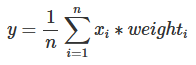

where y is the activity of a TF for a cell, n is the total number of targets for a TF,  xi is the log count expression of target i where i in {1,2,…,n},  "weighti" is the weight of TF and target i.

In [160]:
# Calculate TF activity:

score.combine <- epiregulon::calculateActivity(expMatrix = GeneExpressionMatrix, 
                                   regulon = regulon.w, 
                                   mode = "weight", 
                                   method = "weightedMean", 
                                   exp_assay = "logcounts")

calculating TF activity from regulon using weightedmean

Warning message in epiregulon::calculateActivity(expMatrix = GeneExpressionMatrix, :
"The weight column contains multiple subcolumns but no cluster information was provided. Using first column to compute activity..."
aggregating regulons...

creating weight matrix...

calculating activity scores...

normalize by the number of targets...



In [163]:
head(score.combine[1:5,1:5])

5 x 5 sparse Matrix of class "dgCMatrix"
      10X280_1:CAGATTCAGCAGCTCA 10X365_2:ACCAATATCAATGACC
ADNP                 0.04264355                0.03644435
AEBP2                0.09923847                0.11373224
AFF1                 0.06348621                0.05313250
AFF4                 0.05153624                0.04707332
AGO1                 0.04490426                0.03653942
      10X365_2:ATGGTGCGTCACCTAT 10X280_1:ACACCTTGTCATTAGG
ADNP                 0.03577314                0.03327154
AEBP2                0.07300659                0.11527059
AFF1                 0.05310672                0.05803067
AFF4                 0.04134660                0.04882208
AGO1                 0.03626127                0.04137394
      10X406_1:TATCGCGAGGCTTAAC
ADNP                 0.03523455
AEBP2                0.10853068
AFF1                 0.05654761
AFF4                 0.03901552
AGO1                 0.04142314

In [165]:
# Downstream analysis:

markers  <- epiregulon.extra::findDifferentialActivity(activity_matrix = score.combine, 
                                    clusters = GeneExpressionMatrix$main_cell_types_renamed, 
                                    pval.type = "some", 
                                    direction = "up") # no parameter as "logvalues", though exist in documentation.

In [166]:
markers

List of length 9
names(9): endothelial_cells ... ventricular_zone_progenitor_cells_vz_prog

In [168]:
# getSigGenes compiles the different test results into a single dataframe 
# and enables user to supply their desired cutoffs for significance and variable to order by:

markers.sig <- epiregulon.extra::getSigGenes(markers, topgenes = 3 )

Using a logFC cutoff of 0.1 for class endothelial_cells for direction equal to any

Using a logFC cutoff of 0.1 for class immune_cells for direction equal to any

Using a logFC cutoff of 0.1 for class neurons for direction equal to any

Using a logFC cutoff of 0.1 for class oligodendrocyte_precursors for direction equal to any

Using a logFC cutoff of 0 for class pericytes for direction equal to any

Using a logFC cutoff of 0.1 for class radial_and_glioblast for direction equal to any

Using a logFC cutoff of 0 for class vascular_leptomeningeal_cells_vlmc for direction equal to any

Using a logFC cutoff of 0.1 for class vascular_smooth_muscle_cells for direction equal to any

Using a logFC cutoff of 0 for class ventricular_zone_progenitor_cells_vz_prog for direction equal to any



In [169]:
markers.sig 

,p.value,FDR,summary.logFC,class,tf
,<dbl>,<dbl>,<dbl>,<chr>,<chr>
2,0.000000e+00,0.000000e+00,0.18425751,endothelial_cells,BCL6B
7,0.000000e+00,0.000000e+00,0.16633704,endothelial_cells,FOXF2
3,0.000000e+00,0.000000e+00,0.16043171,endothelial_cells,SOX17
21,0.000000e+00,0.000000e+00,0.18495630,immune_cells,IRF8
17,0.000000e+00,0.000000e+00,0.16882958,immune_cells,XPO1
8,0.000000e+00,0.000000e+00,0.15169599,immune_cells,CD74
1,0.000000e+00,0.000000e+00,0.10224708,neurons,LMO1
11,0.000000e+00,0.000000e+00,0.10834299,oligodendrocyte_precursors,PHF19
10,0.000000e+00,0.000000e+00,0.16945444,pericytes,FOXF2


In [172]:
# Visualize TF activities:

options(ggrastr.default.dpi=300)

tfs_interest <- c("BCL6B","FOXF2", "SOX17","CD74")

p1 <- epiregulon.extra::plotActivityDim(sce = PeakMatrix,
                activity_matrix = score.combine[tfs_interest,], 
                tf = tfs_interest, 
                dimtype = "UMAP_ATAC",
                nrow=2,
                ncol=2,
                point_size=0.1,
                rasterise = TRUE)

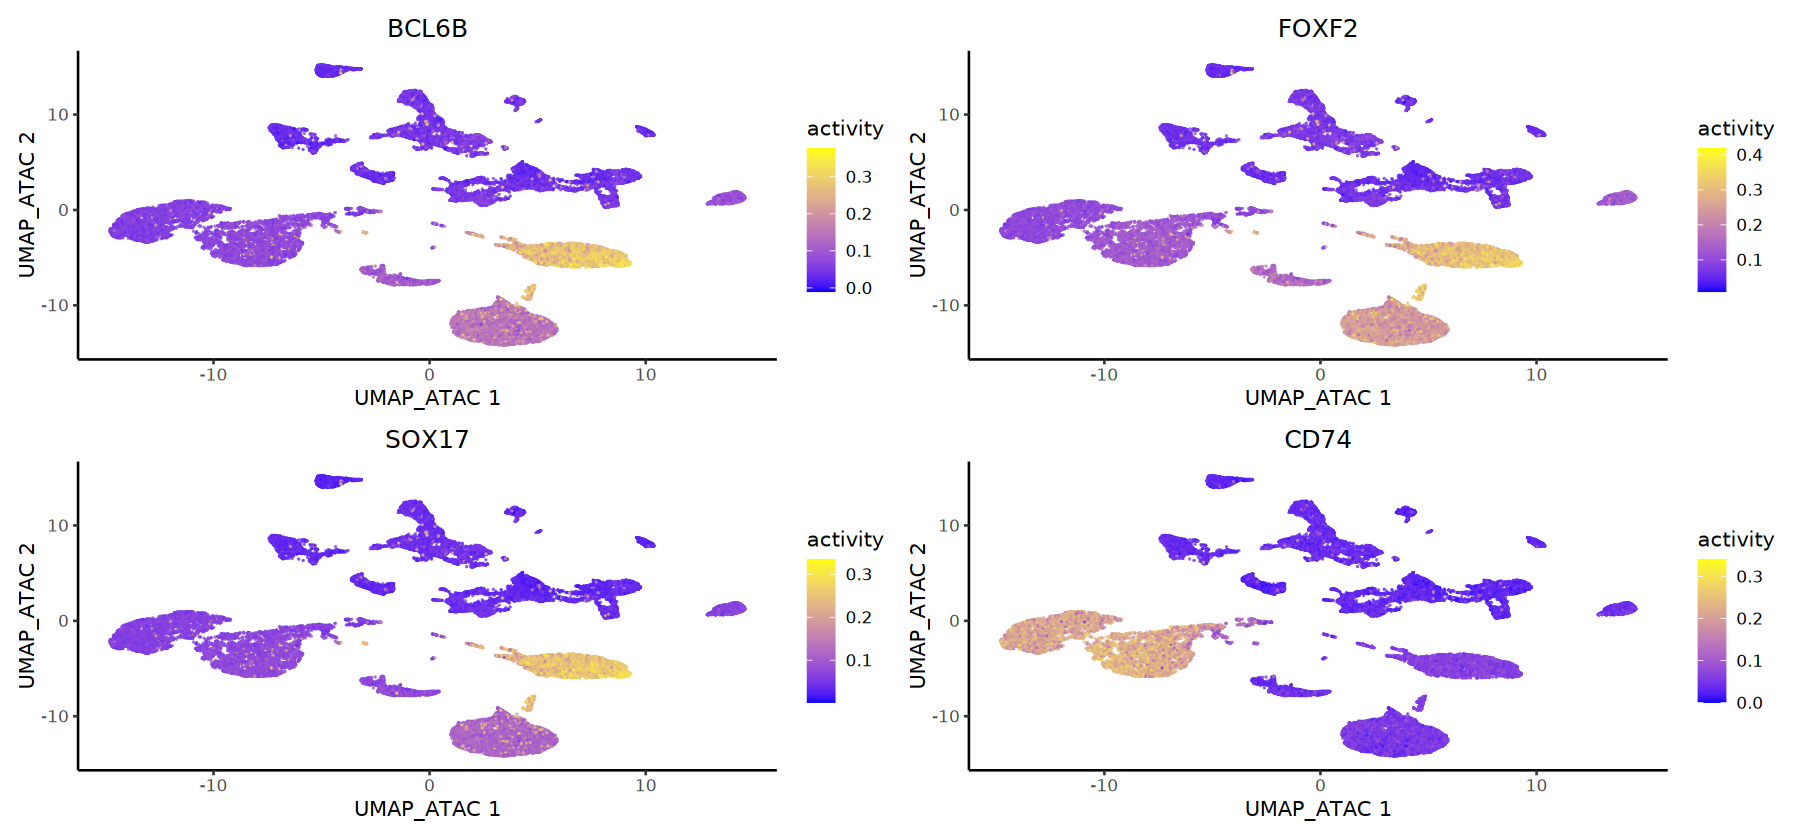

In [173]:
options(repr.plot.width = 15, repr.plot.height = 7)

print(p1)

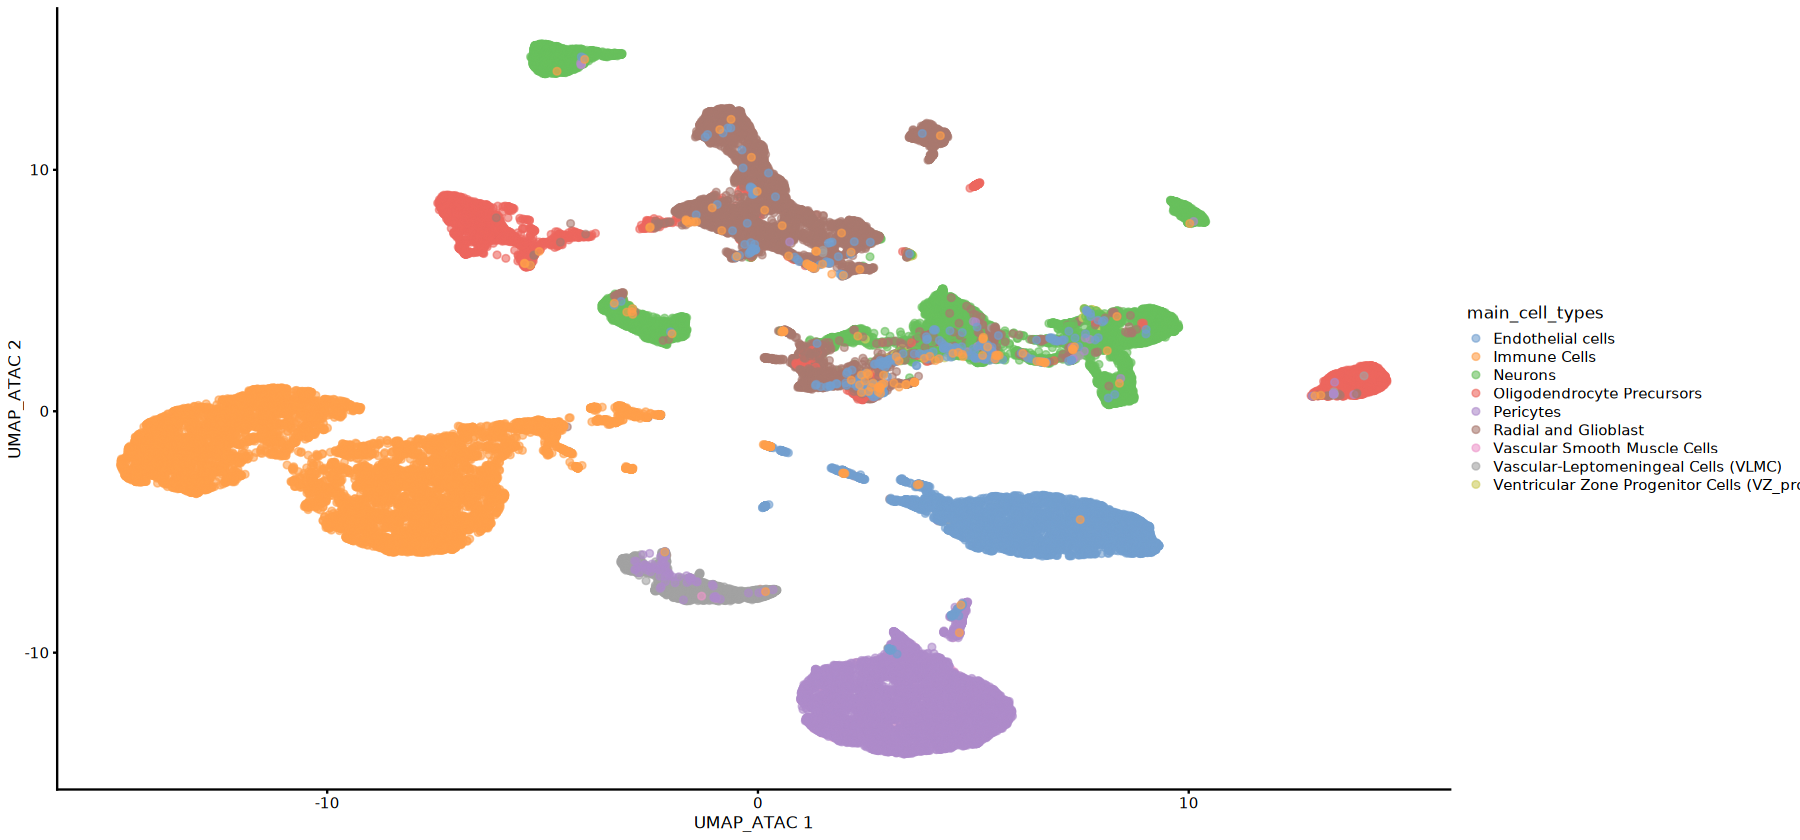

In [174]:
scater::plotReducedDim(object = PeakMatrix, dimred = 'UMAP_ATAC', colour_by = 'main_cell_types')

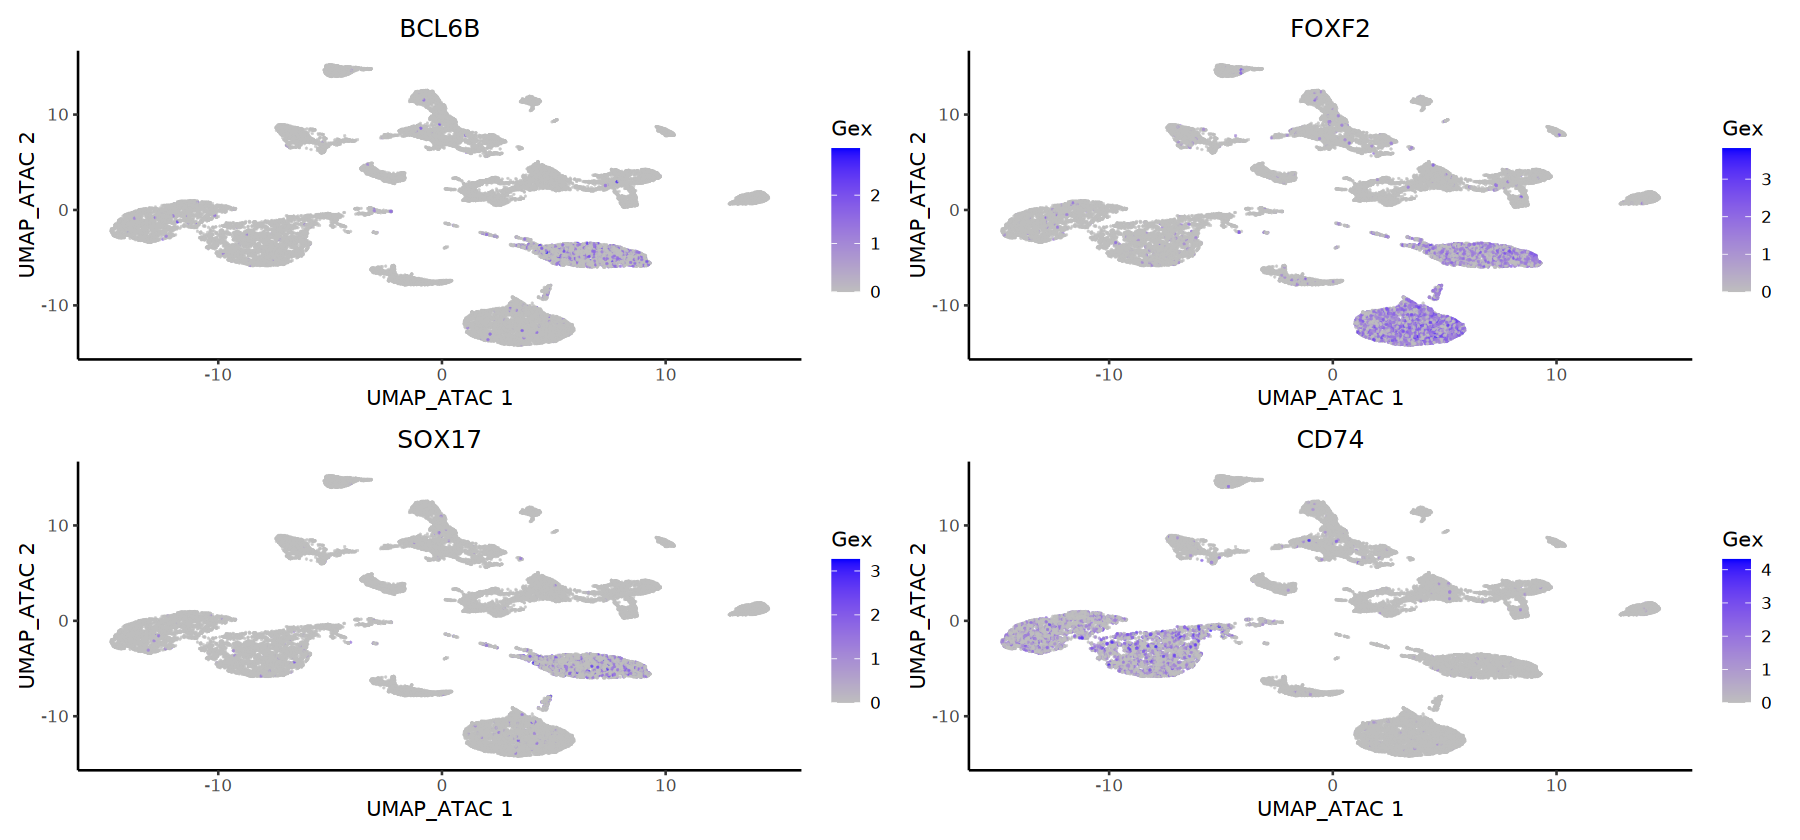

In [175]:
# Visualize expression values of the same TFs, projected on ATAC UMAP as above:

epiregulon.extra::plotActivityDim(sce = PeakMatrix, 
                activity_matrix = assay(GeneExpressionMatrix, "logcounts")[tfs_interest,], 
                tf = tfs_interest, 
                dimtype = "UMAP_ATAC",
                nrow=2,
                ncol=2,
                legend.label = "Gex",
                colors = c("grey","blue"),
                point_size=0.1,
                rasterise = TRUE)

In [176]:
options(repr.plot.width = 15, repr.plot.height = 10)

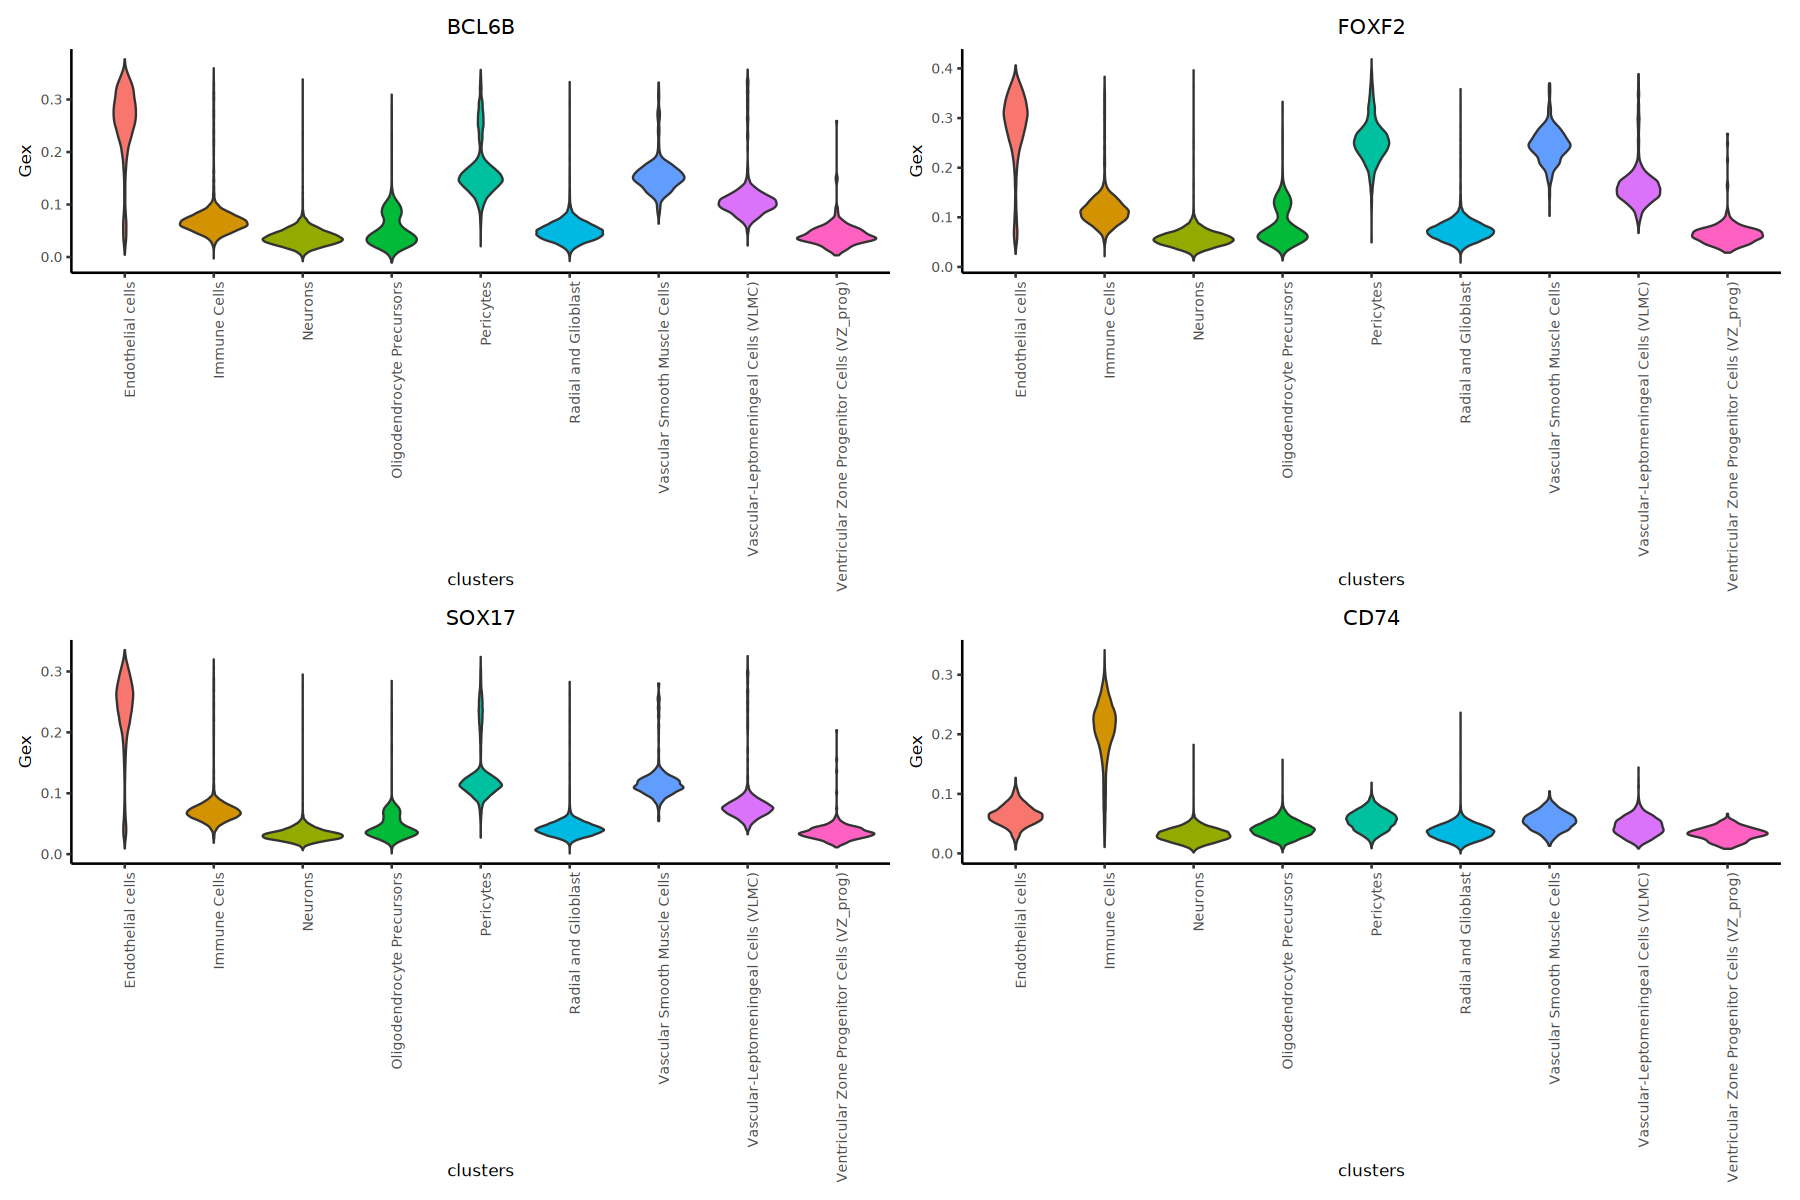

In [178]:
# TF activies as violin plots across cell types:

epiregulon.extra::plotActivityViolin(activity_matrix = score.combine, 
                   tf = tfs_interest, 
                   clusters = GeneExpressionMatrix$main_cell_types,
                   legend.label = "Gex",
                   nrow=2,
                   ncol=2)

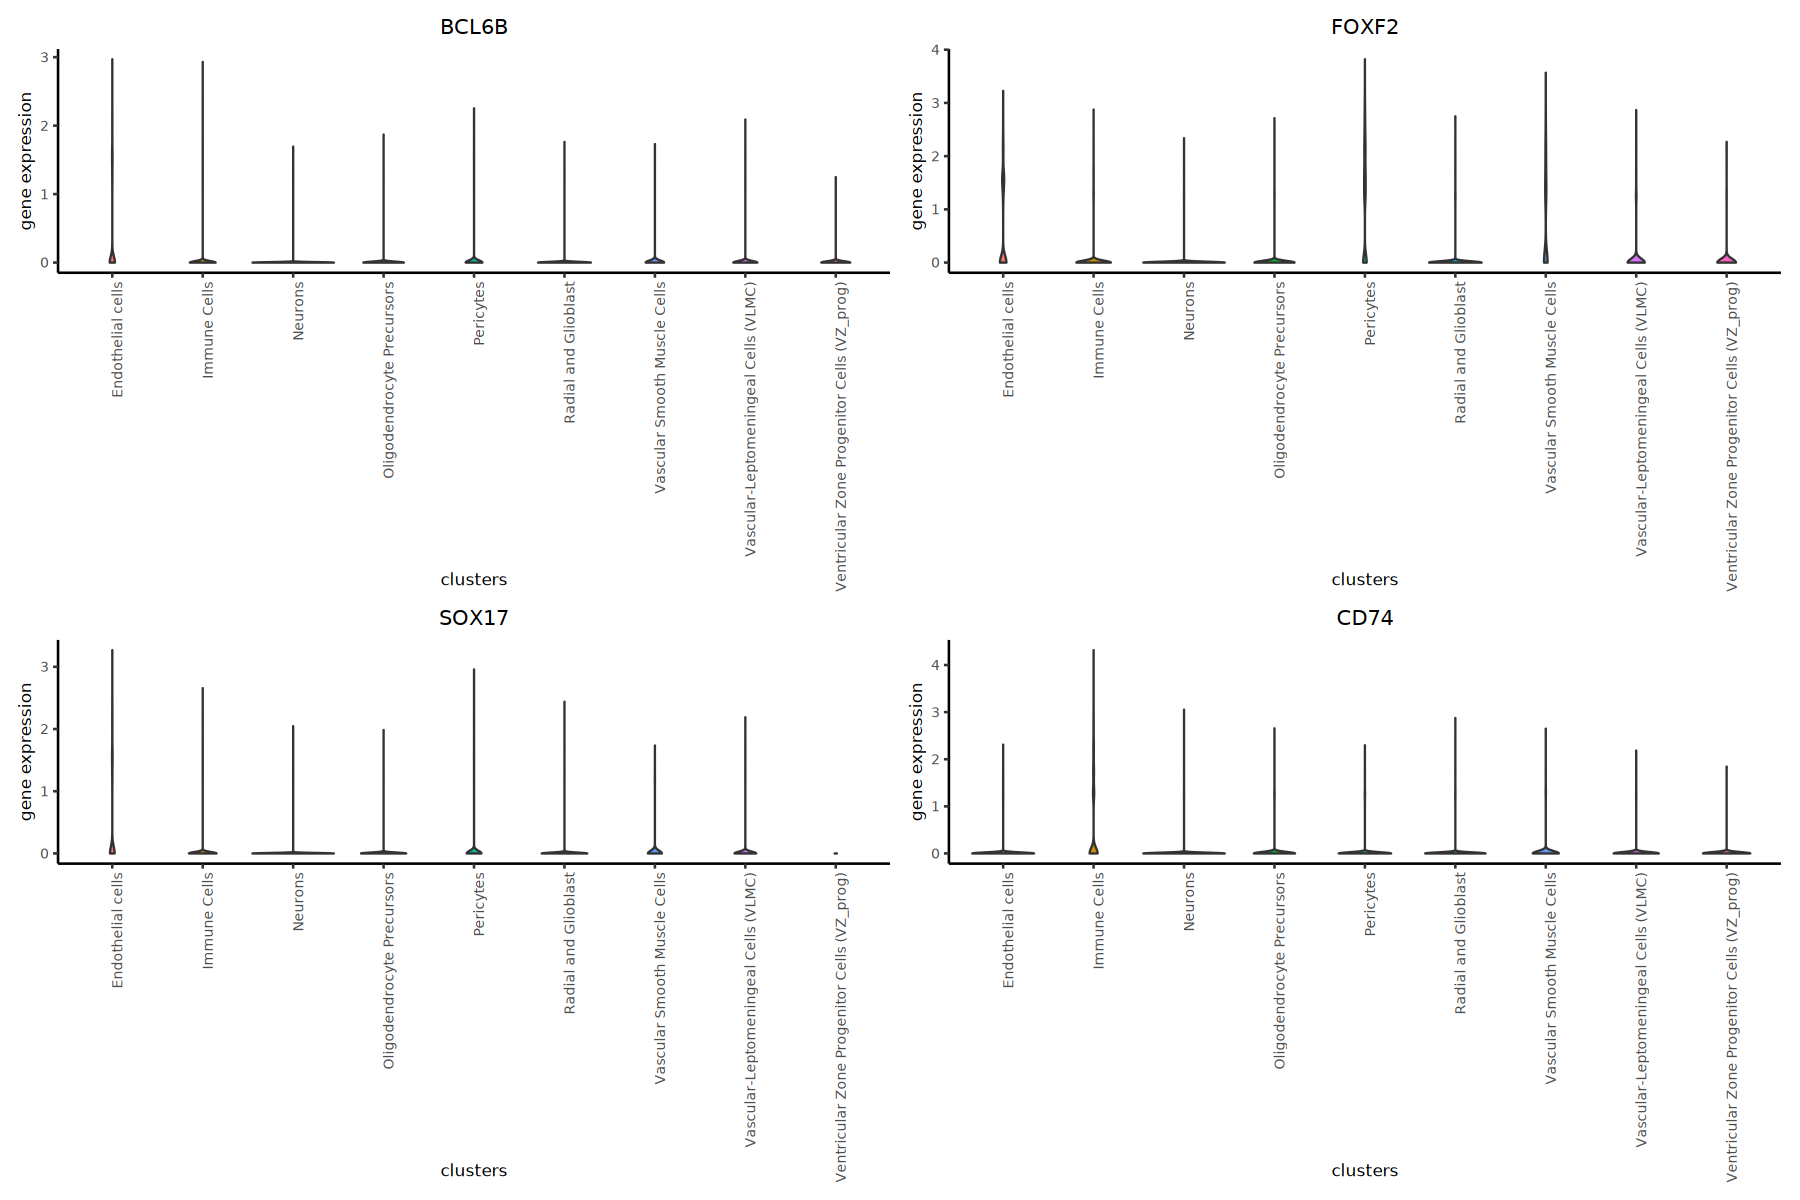

In [179]:
# Expression values of same TFs:

epiregulon.extra::plotActivityViolin(
                                   activity_matrix = assay(GeneExpressionMatrix, "logcounts")[tfs_interest,],  
                                   tf = tfs_interest, 
                                   clusters = GeneExpressionMatrix$main_cell_types,
                                   nrow=2,
                                   ncol=2,
                                   legend.label = "gene expression"  )

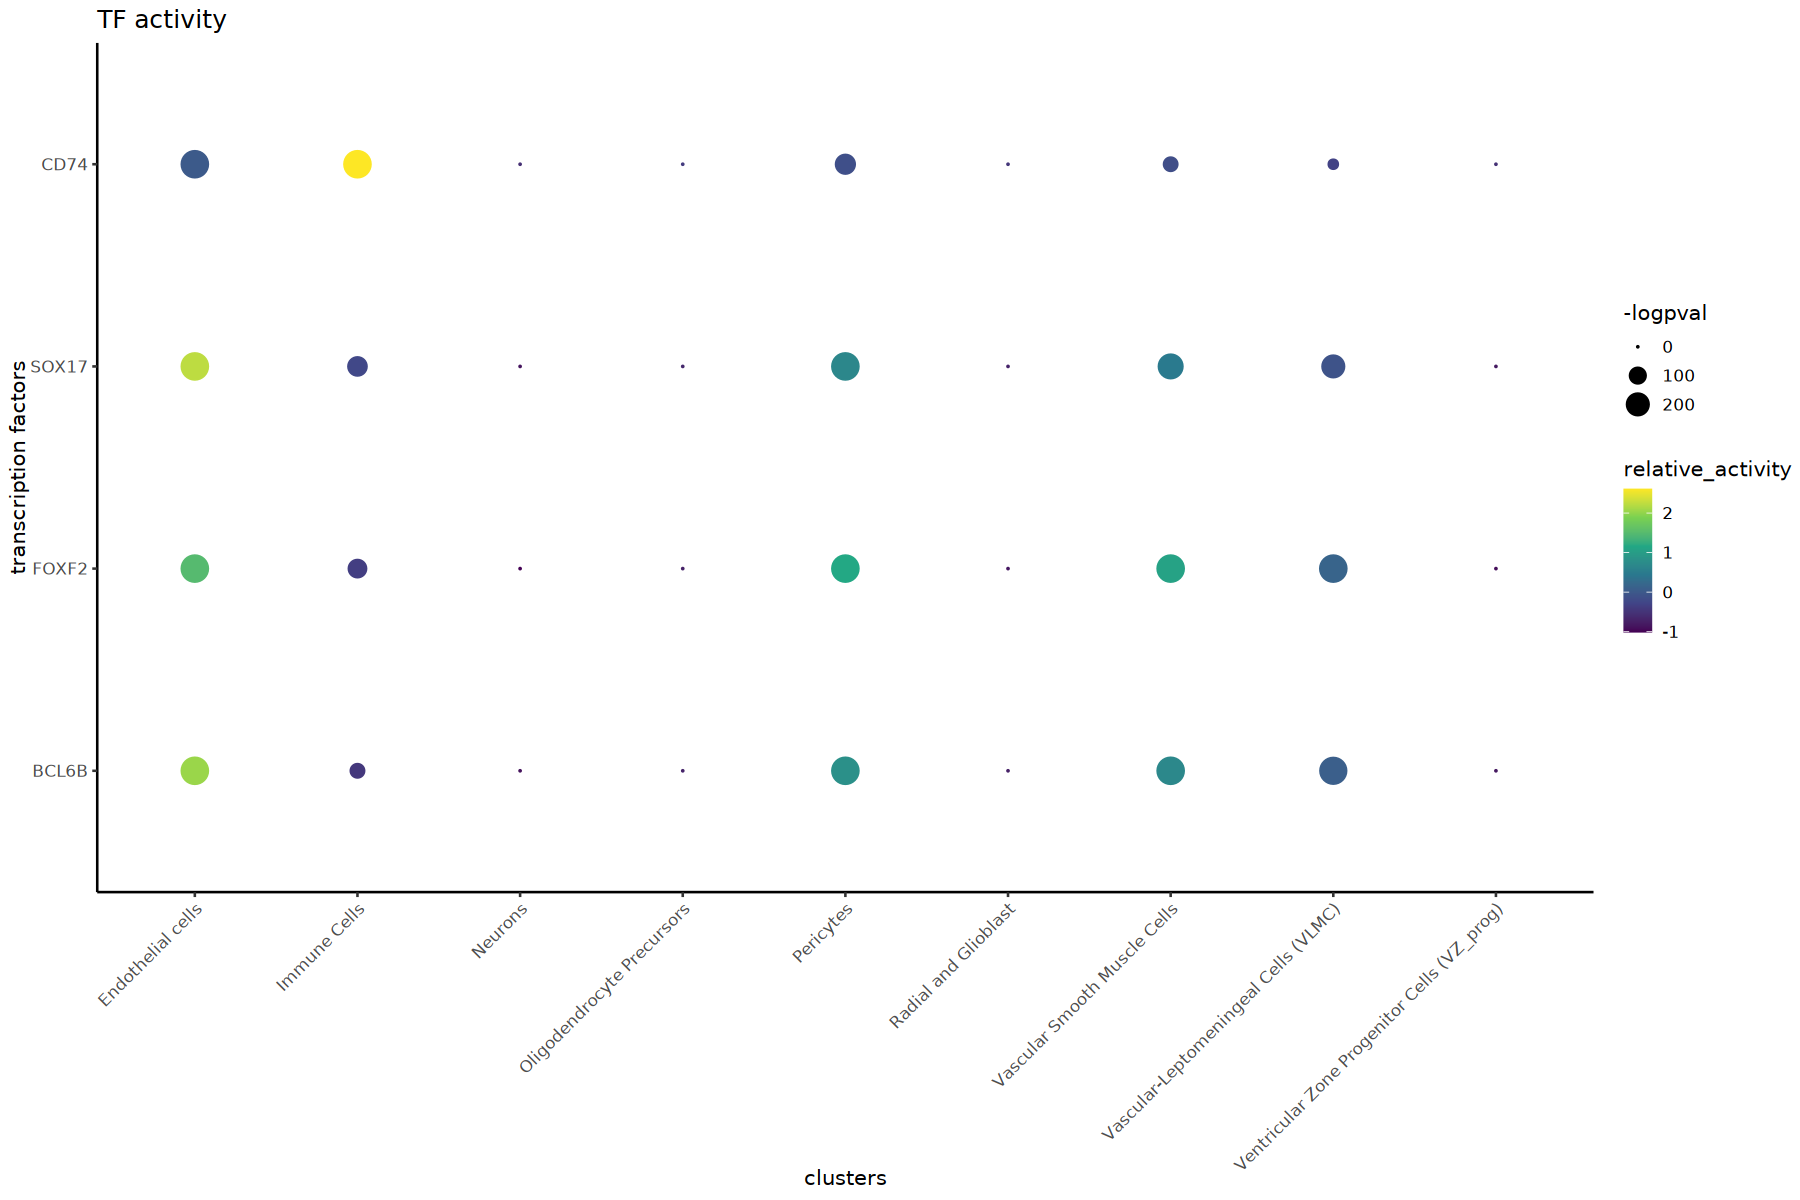

In [181]:
# TF activities as dot plots across cell types:

epiregulon.extra::plotBubble(activity_matrix = score.combine, 
           tf = tfs_interest,
           GeneExpressionMatrix$main_cell_types,
           pval.type = "some", 
           direction = "up", 
           # logvalues = FALSE # this argument is no longer available. maybe the function is updated. 
           )

In [189]:
# default axis font size: 

my_theme <- ggplot2::theme(
    axis.title.x = ggplot2::element_text(size = 14),  # X-axis title size
    axis.title.y = ggplot2::element_text(size = 14),  # Y-axis title size
    axis.text.x  = ggplot2::element_text(size = 14, angle = 45, hjust = 1),  # X-axis tick labels
    axis.text.y  = ggplot2::element_text(size = 14),  # Y-axis tick labels
    legend.text  = ggplot2::element_text(size = 15)   # Legend text size
)

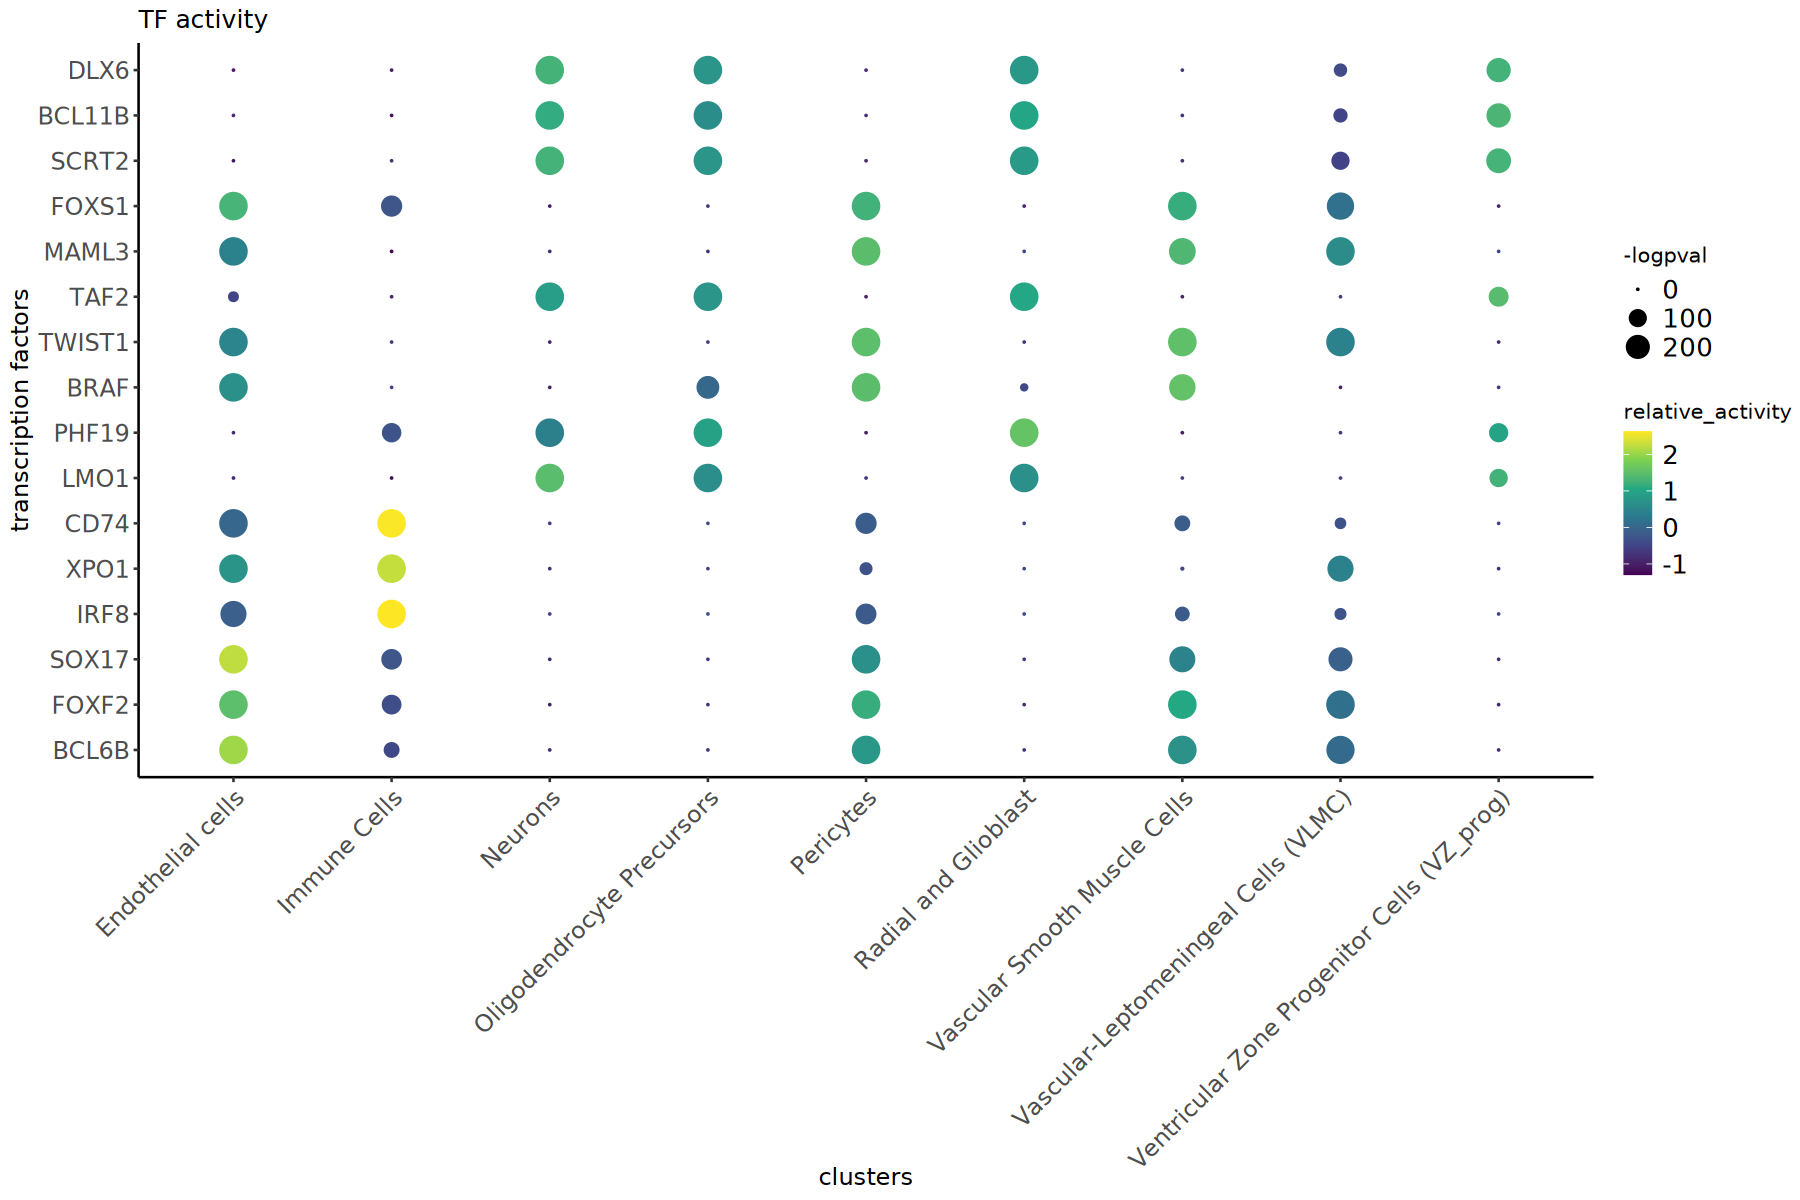

In [190]:
# Visualize top differential TFs:

epiregulon.extra::plotBubble(activity_matrix = score.combine, 
           tf = markers.sig$tf, 
           GeneExpressionMatrix$main_cell_types,
           pval.type = "some", 
           direction = "up", 
           # logvalues = FALSE # this argument is giving error as being unused. maybe the function is updated. 
           ) + my_theme

In [192]:
# To inspect what pathways are enriched in the regulon of a particular TF. 
# We can perform geneset enrichment using the enricher function from clusterProfiler.

# Here we first download Hallmark and C2 signatures from hallmark and then perform 
# gene set enrichment.

#retrieve genesets:

H <- EnrichmentBrowser::getGenesets(org = "hsa", 
                                    db = "msigdb", 
                                    cat = "H", 
                                    gene.id.type = "SYMBOL" )
C2 <- EnrichmentBrowser::getGenesets(org = "hsa", 
                                     db = "msigdb", 
                                     cat = "C2",
                                     gene.id.type = "SYMBOL" )


#combine genesets and convert genesets to be compatible with enricher
gs <- c(H, C2)
gs.list <- do.call(rbind,lapply(names(gs), function(x) 
  {data.frame(gs=x, genes=gs[[x]])}))

enrichresults <- epiregulon.extra::regulonEnrich(TF = tfs_interest, 
                               regulon = regulon.w, 
                               weight = "weight",
                               weight_cutoff = 0, 
                               genesets = gs.list)

BCL6B



FOXF2

SOX17

CD74



In [199]:
#plot results

p1 <- epiregulon.extra::enrichPlot(results = enrichresults, ncol=2)

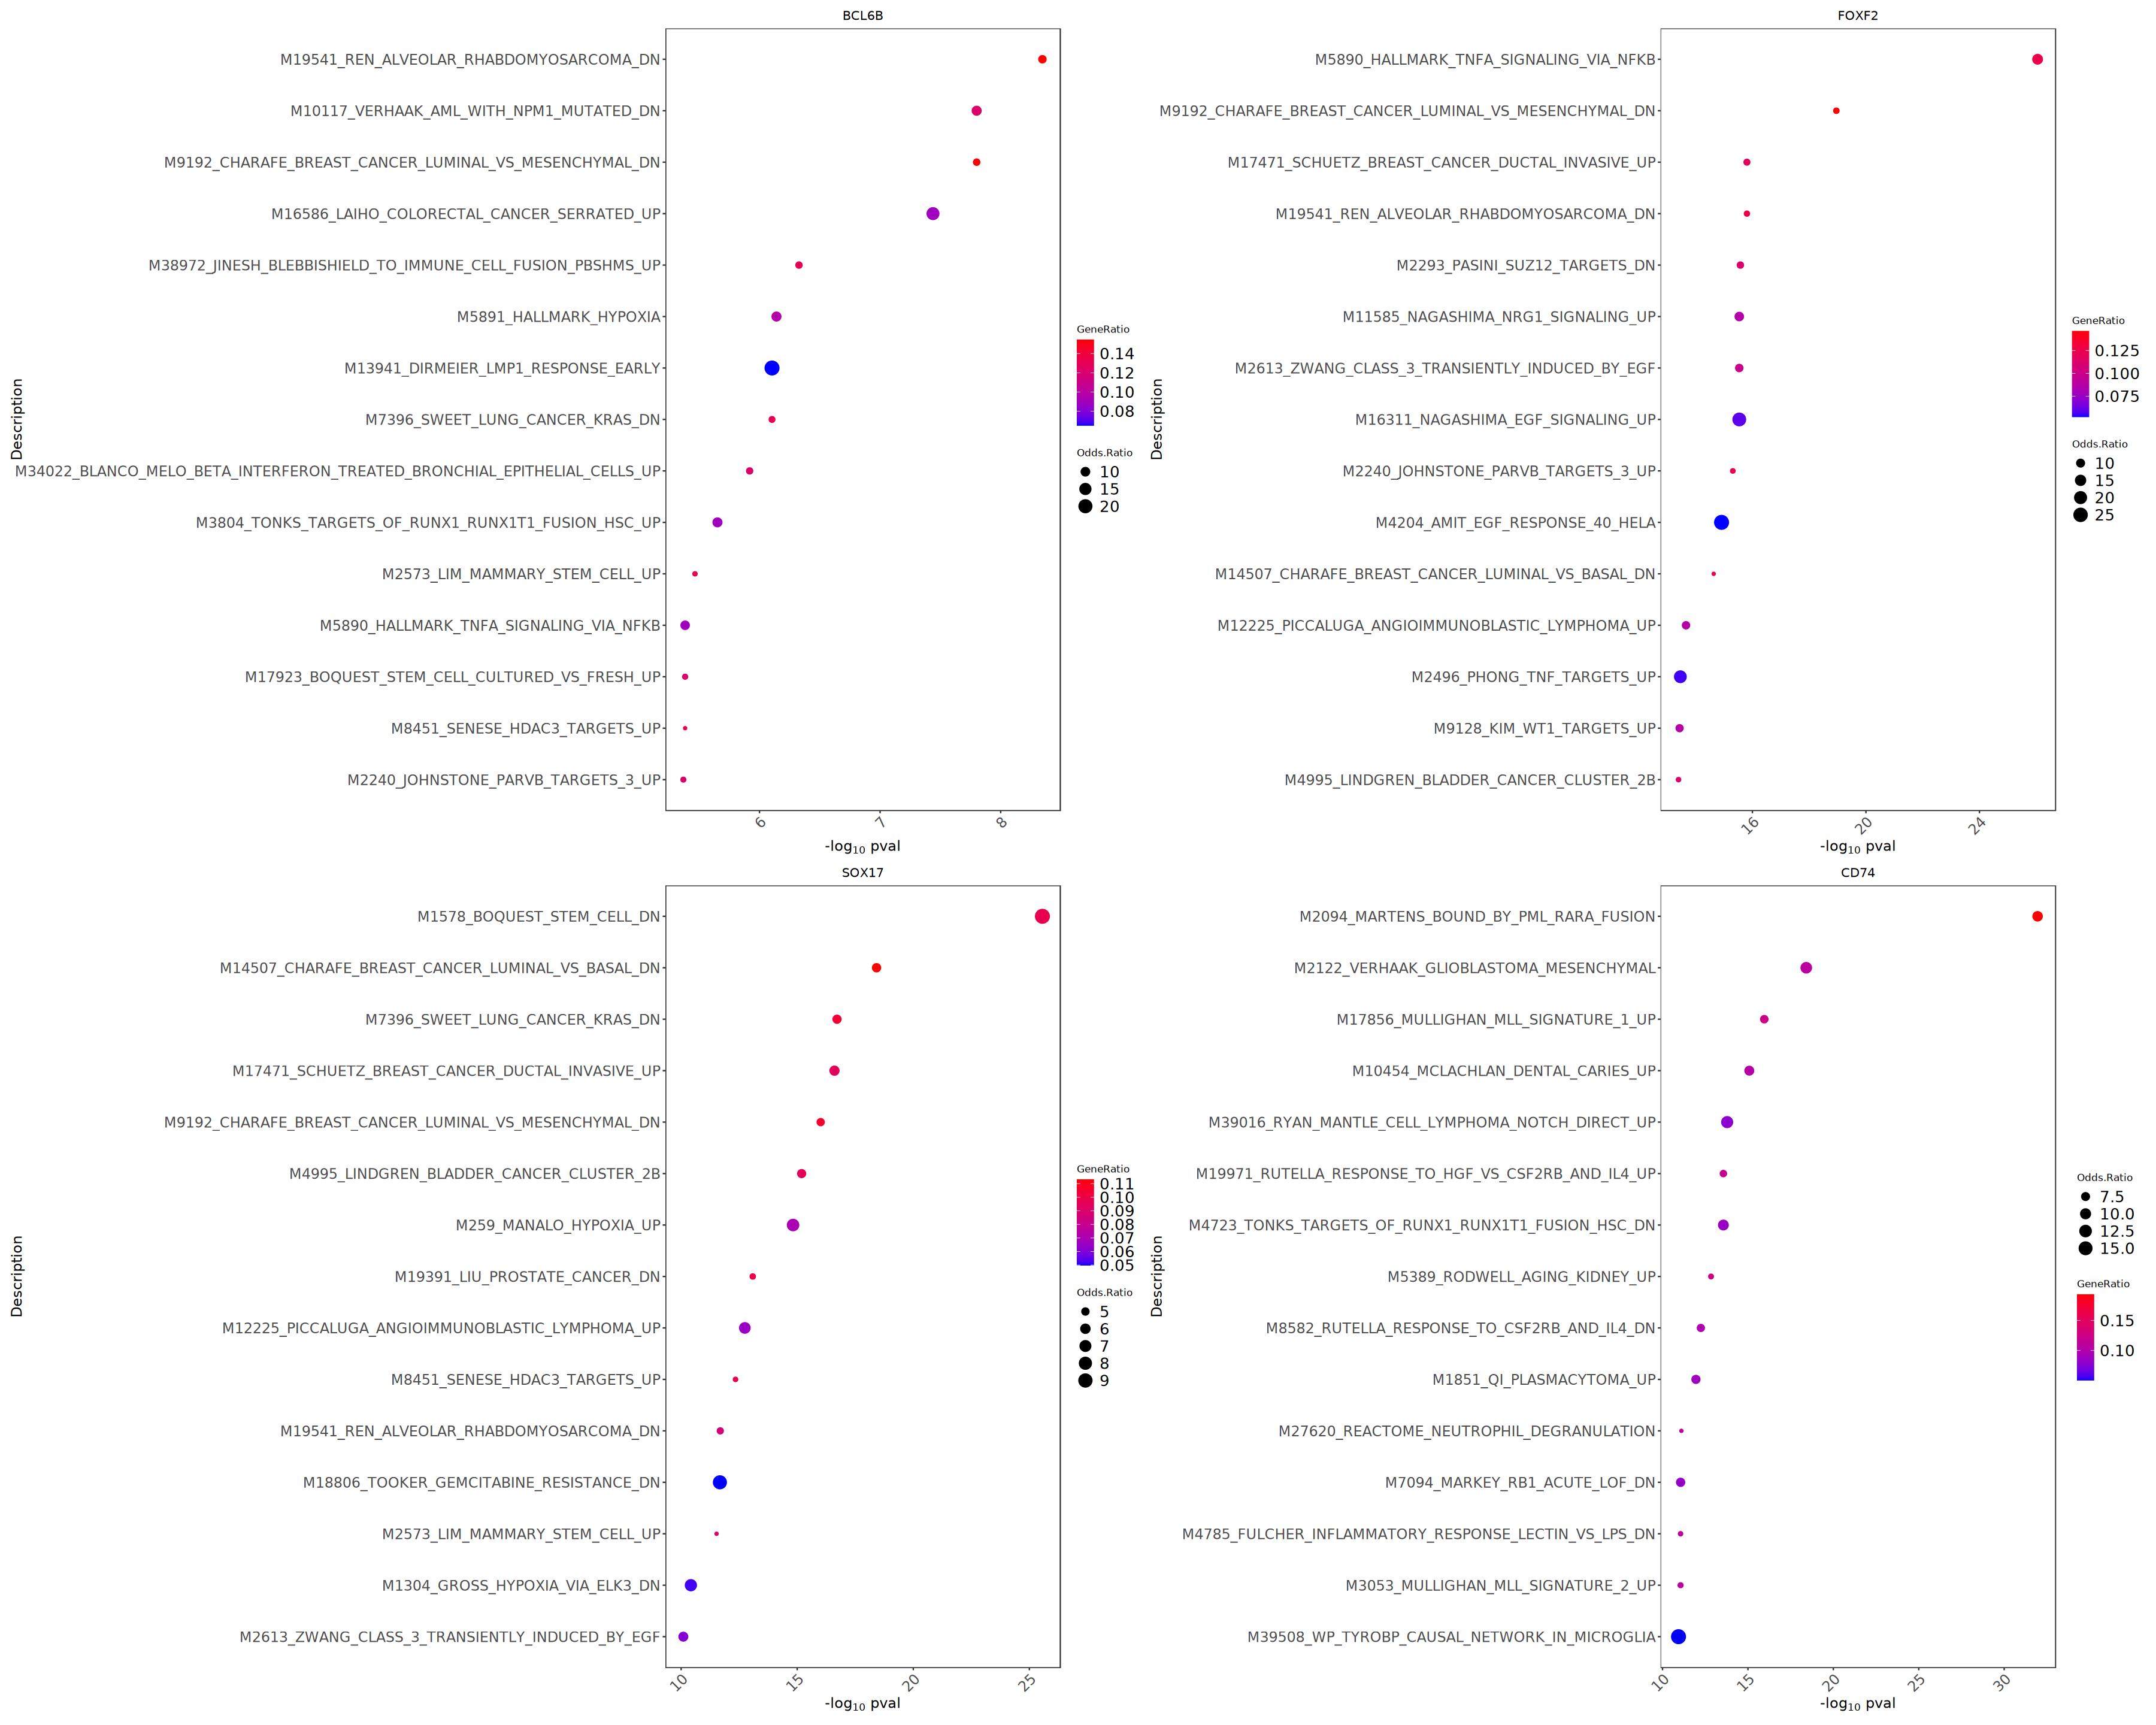

In [203]:
options(repr.plot.width = 30, repr.plot.height = 24)

p1 & my_theme # apply the theme to all constituent plots:

options(repr.plot.width = 17, repr.plot.height = 7)  # set the options back after imaging.

Building graph using weight as edge weights



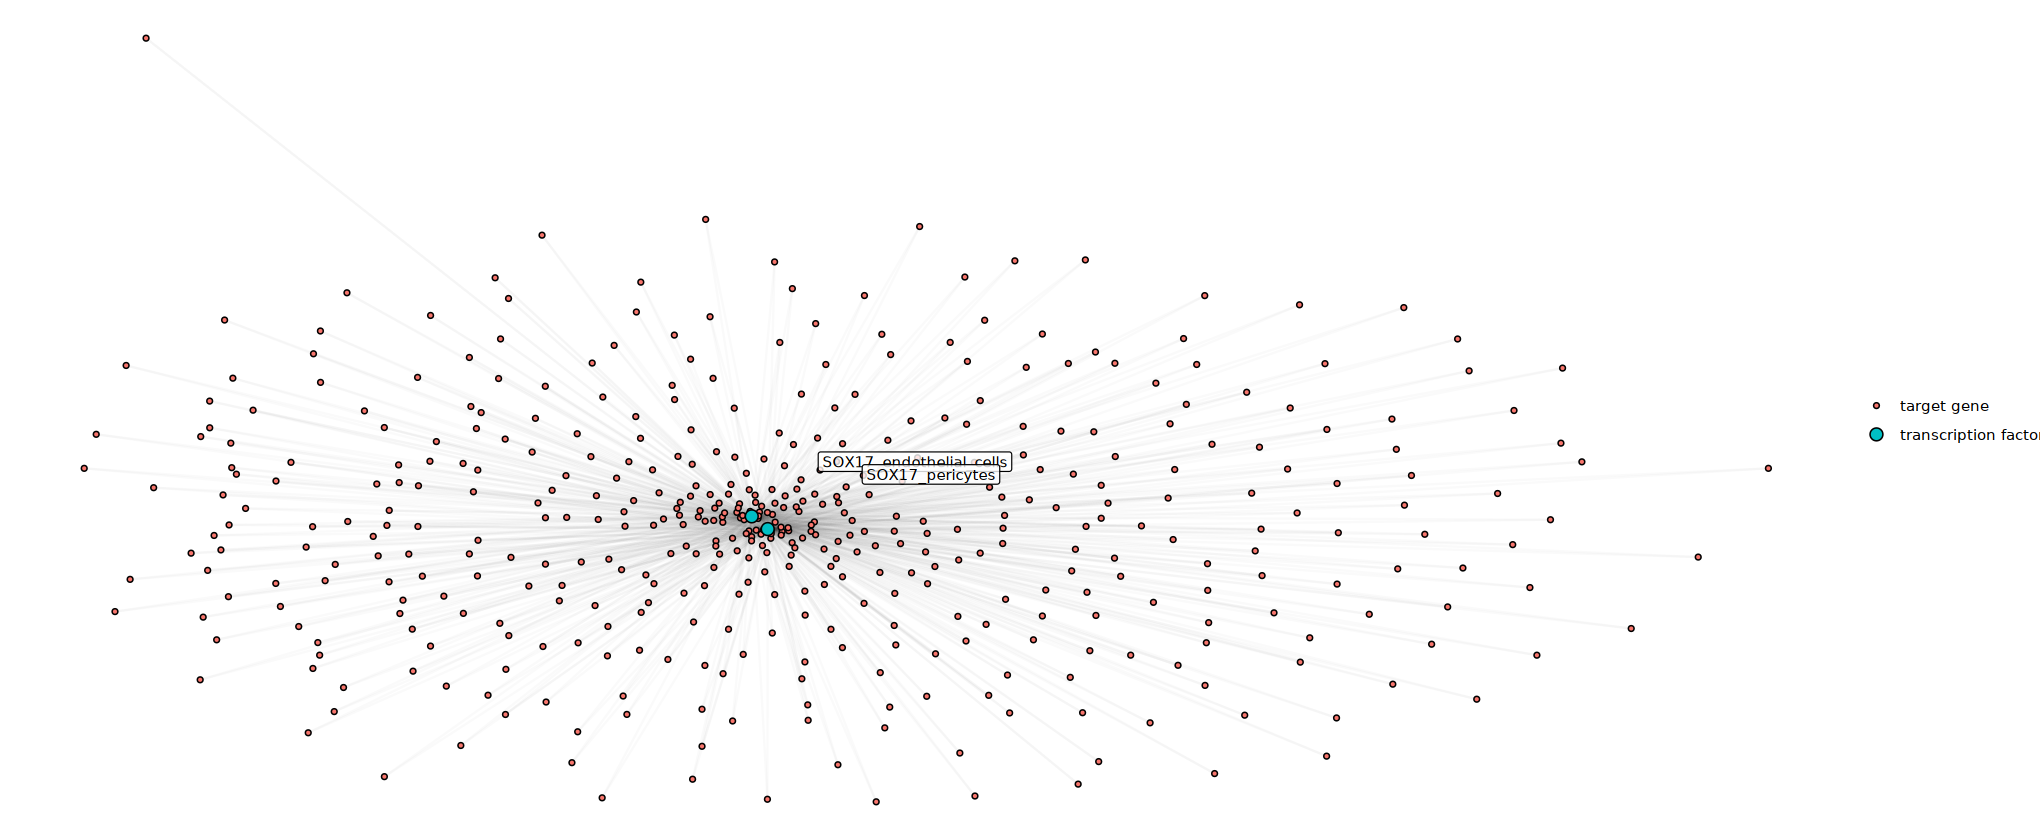

In [205]:
# In addition to looking at the summed TF activity, a second approach to investigate 
# differential TF activity is to compare and contrast target genes or network topology. 
# I will plot the differential network of SOX17 using the regulon with cluster-specific weights, 
# focusing on endothelial cells and pericytes.

epiregulon.extra::plotDiffNetwork(regulon.w,
                cutoff = 0,
                tf = c("SOX17"),
                weight = "weight",
                clusters = c("endothelial_cells","pericytes"),
                layout = "stress")

In [210]:
# To identify interaction partners of the TFs of interest,
# one can compare the overlap of the targets genes for all the TFs 
# and identify the most similar TFs by Jaccard similarity.  
# Below, I take a look at the top most similar 20 TFs to SOX17.

In [211]:
library(ggplot2)

# construct a graph of the endothelial cells

ec_network <- epiregulon.extra::buildGraph(regulon.w, weights = "weight", cluster="endothelial_cells")

Building graph using weight as edge weights



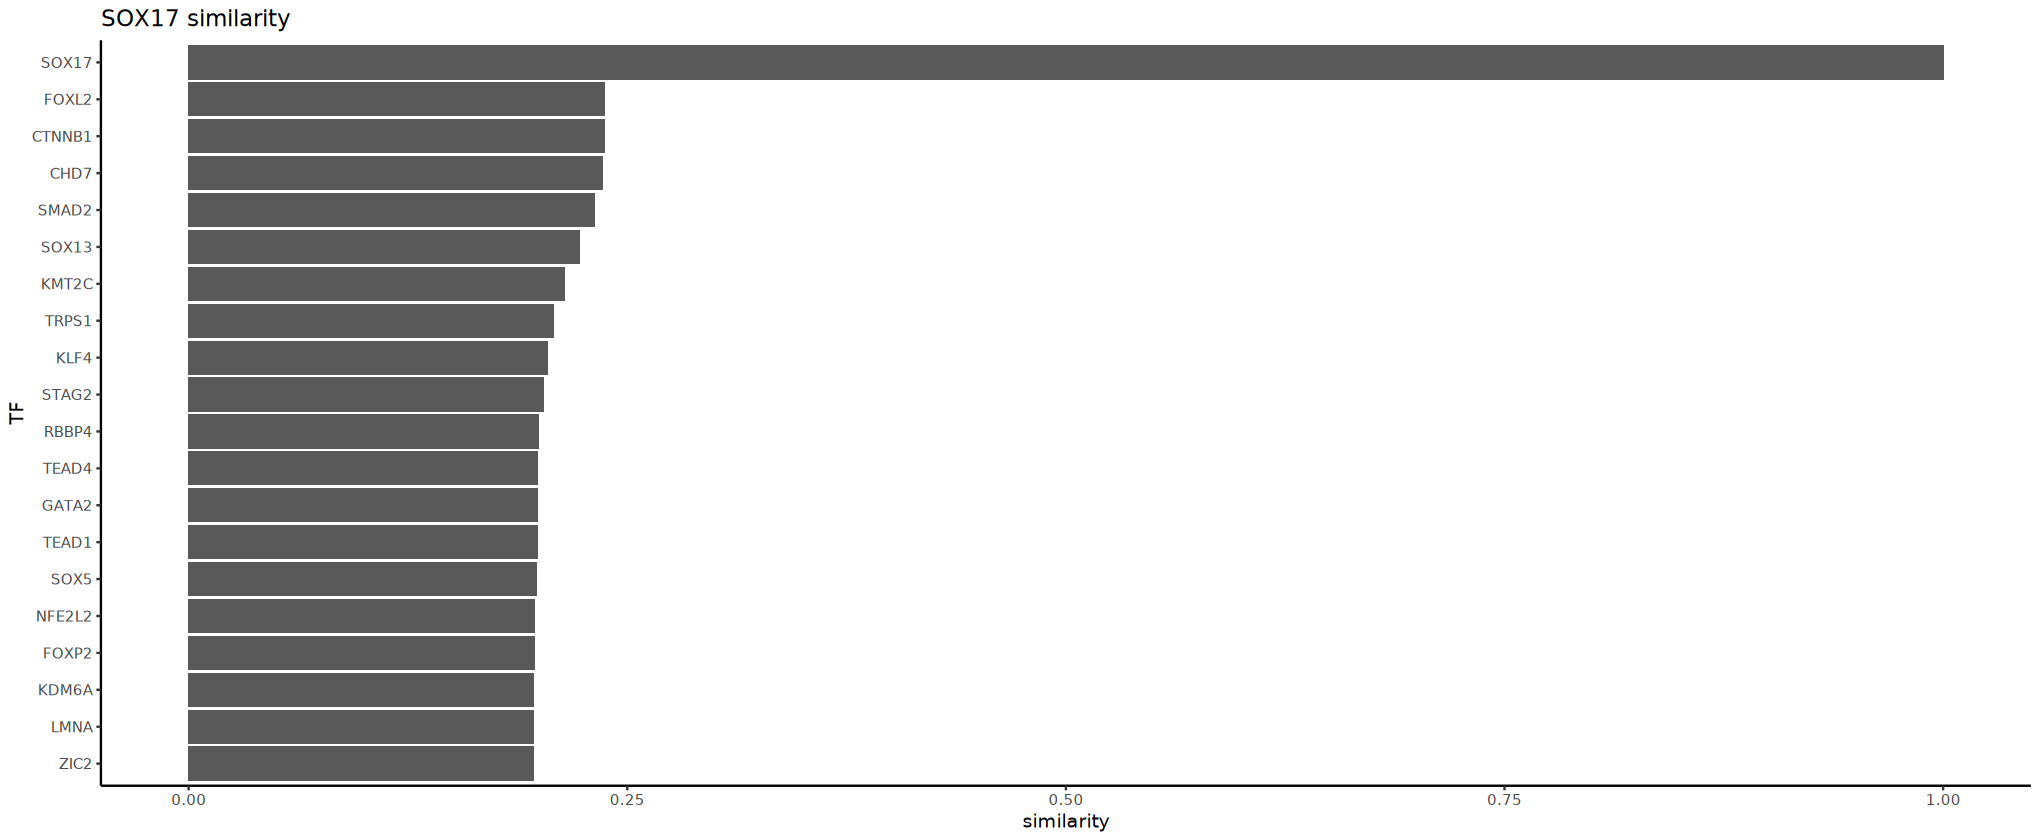

In [212]:
# compute a similarity matrix of all TFs:

similarity_score <- epiregulon.extra::calculateJaccardSimilarity(ec_network)

# Focus on SOX17:

similarity_score_SOX17 <- similarity_score[, "SOX17"]
similarity_df <- data.frame(similarity = head(sort(similarity_score_SOX17, 
                                                   decreasing = TRUE),20),
                            TF = names(head(sort(similarity_score_SOX17,
                                                 decreasing = TRUE),20)))

similarity_df$TF <- factor(similarity_df$TF, levels = rev(unique(similarity_df$TF)))

# plot top TFs most similar to SOX17:

topTFplot <- ggplot(similarity_df, aes(x=TF, y=similarity)) +
  geom_bar(stat="identity") +
  coord_flip() +
  ggtitle("SOX17 similarity") +
  theme_classic()

print(topTFplot)

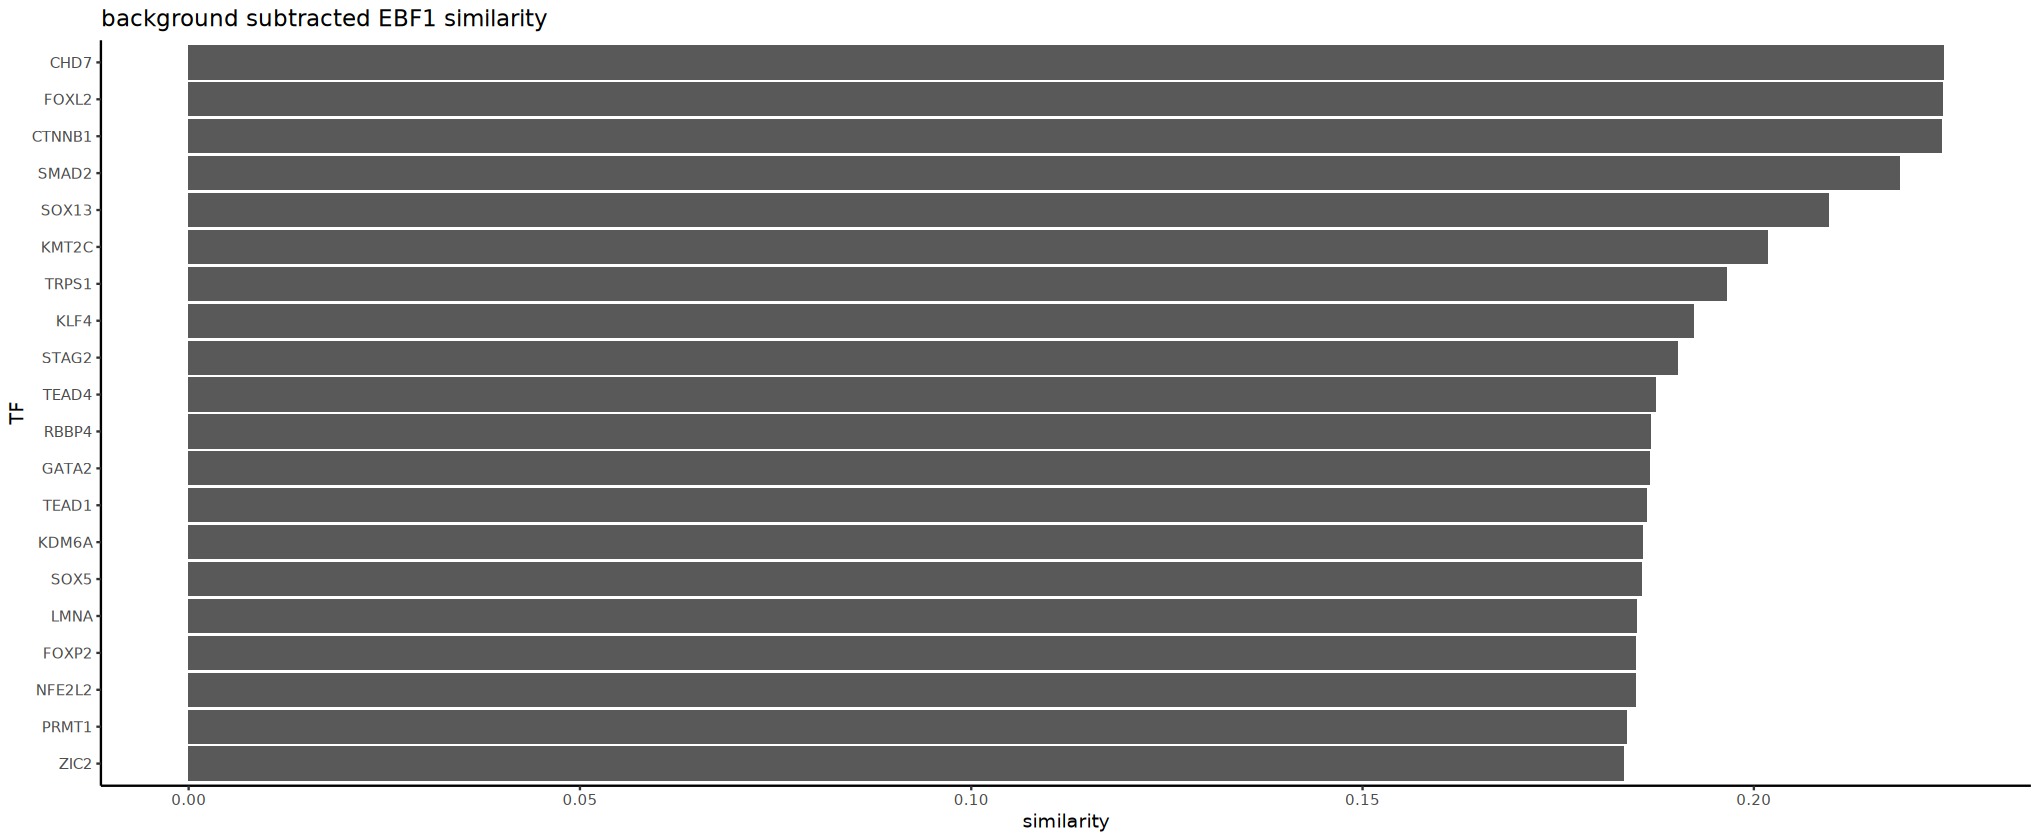

In [215]:
# In order to convince ourselves that our differential network is statistically significant, 
# we permute the edges and obtain a background graph from averaging many iterations. 
# Here, we plot the differential network graph subtracted by permuted graphs.


# create a permuted graph by rewiring the edges 100 times

permute_matrix <- epiregulon.extra::permuteGraph(ec_network, "SOX17", 100, p=1)
permute_matrix <- permute_matrix[names(similarity_score_SOX17),]
diff_matrix <- similarity_score_SOX17-rowMeans(permute_matrix)

diff_matrix_df <- data.frame(similarity = head(sort(diff_matrix, 
                                                    decreasing = TRUE),20),
                            TF = names(head(sort(diff_matrix,
                                                 decreasing = TRUE),20)))

diff_matrix_df$TF <- factor(diff_matrix_df$TF, levels = rev(unique(diff_matrix_df$TF)))

# plot top TFs most similar to SOX17:

topTFplot <- ggplot(diff_matrix_df, aes(x=TF, y=similarity)) +
            geom_bar(stat="identity") +
            coord_flip() +
            ggtitle("background subtracted EBF1 similarity ") +
            theme_classic()
print(topTFplot)

In [217]:
# Obtain empirical p-values for each TF that were tested for similarity to SOX17 :

p_matrix <- rowMeans(apply(permute_matrix, 2, function(x) {x > similarity_score_SOX17}))
p_matrix[names(head(sort(diff_matrix,decreasing = TRUE),20))] |> print()

  CHD7  FOXL2 CTNNB1  SMAD2  SOX13  KMT2C  TRPS1   KLF4  STAG2  TEAD4  RBBP4 
     0      0      0      0      0      0      0      0      0      0      0 
 GATA2  TEAD1  KDM6A   SOX5   LMNA  FOXP2 NFE2L2  PRMT1   ZIC2 
     0      0      0      0      0      0      0      0      0 


In [220]:
# Next, we are interested to compare the networks of two cell types, in this case, 
# endothelial cells vs pericytes. We build an edge 
# subtracted graph and then calculate the degree centrality of the subtracted 
# graph. We normalize centrality using the default square root function. 

# construct a graph of the Endotehlial Cells and Pericytes, respectively

ec_network <- epiregulon.extra::buildGraph(regulon.w, weights = "weight", cluster="endothelial_cells")

pericytes_network <- epiregulon.extra::buildGraph(regulon.w, weights = "weight", cluster="pericytes")

Building graph using weight as edge weights

Building graph using weight as edge weights



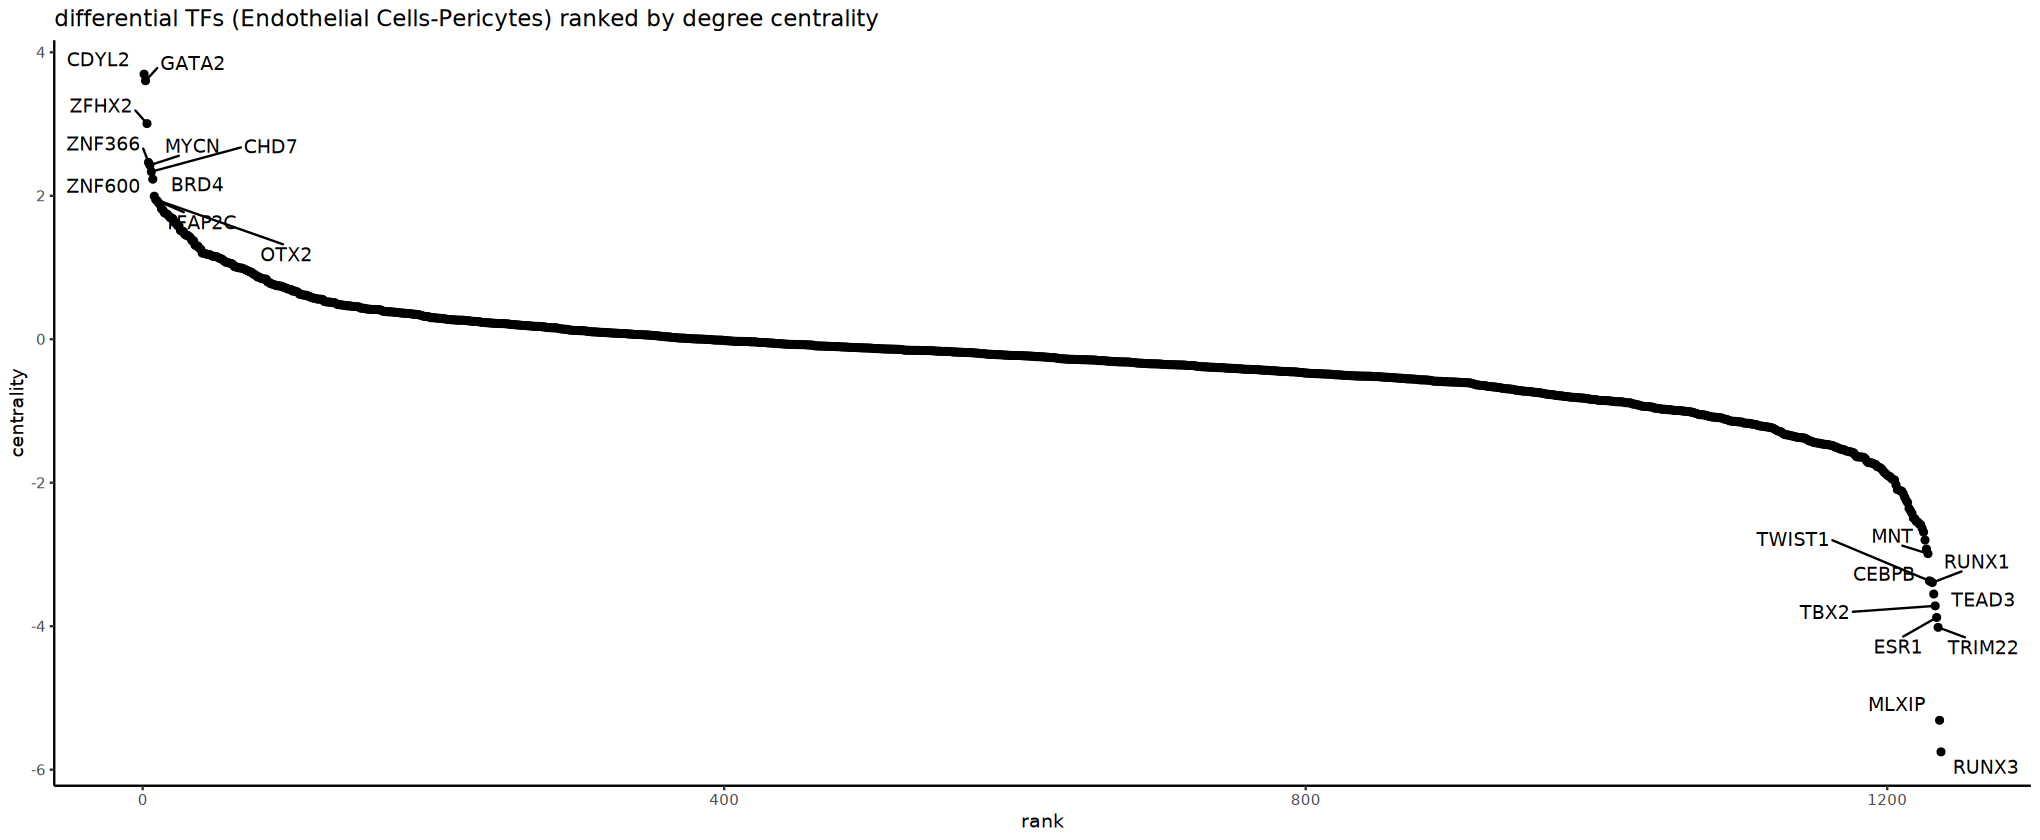

In [221]:
# construct a difference graph:

diff_graph <- epiregulon.extra::buildDiffGraph(ec_network, pericytes_network, abs_diff = FALSE)
diff_graph <- epiregulon.extra::addCentrality(diff_graph)
diff_graph <- epiregulon.extra::normalizeCentrality(diff_graph)
rank_table <- epiregulon.extra::rankTfs(diff_graph)

library(ggplot2)
ggplot(rank_table, aes(x = rank, y = centrality)) +
    geom_point() +
    ggrepel::geom_text_repel(data = rbind(head(rank_table, 10), 
                                          tail(rank_table, 10)), 
                             aes(label = tf), 
                             nudge_x = 0, nudge_y = 0, box.padding = 0.5, max.overlaps = Inf) +
    theme_classic() + ggtitle ("differential TFs (Endothelial Cells-Pericytes) ranked by degree centrality")

In [226]:
# We can further explore interacting factors with the CHD7
# using the same Jaccard similarity approach:

In [227]:
library(igraph)

Warning message:
"`subgraph.edges()` was deprecated in igraph 2.1.0.
i Please use `subgraph_from_edges()` instead."


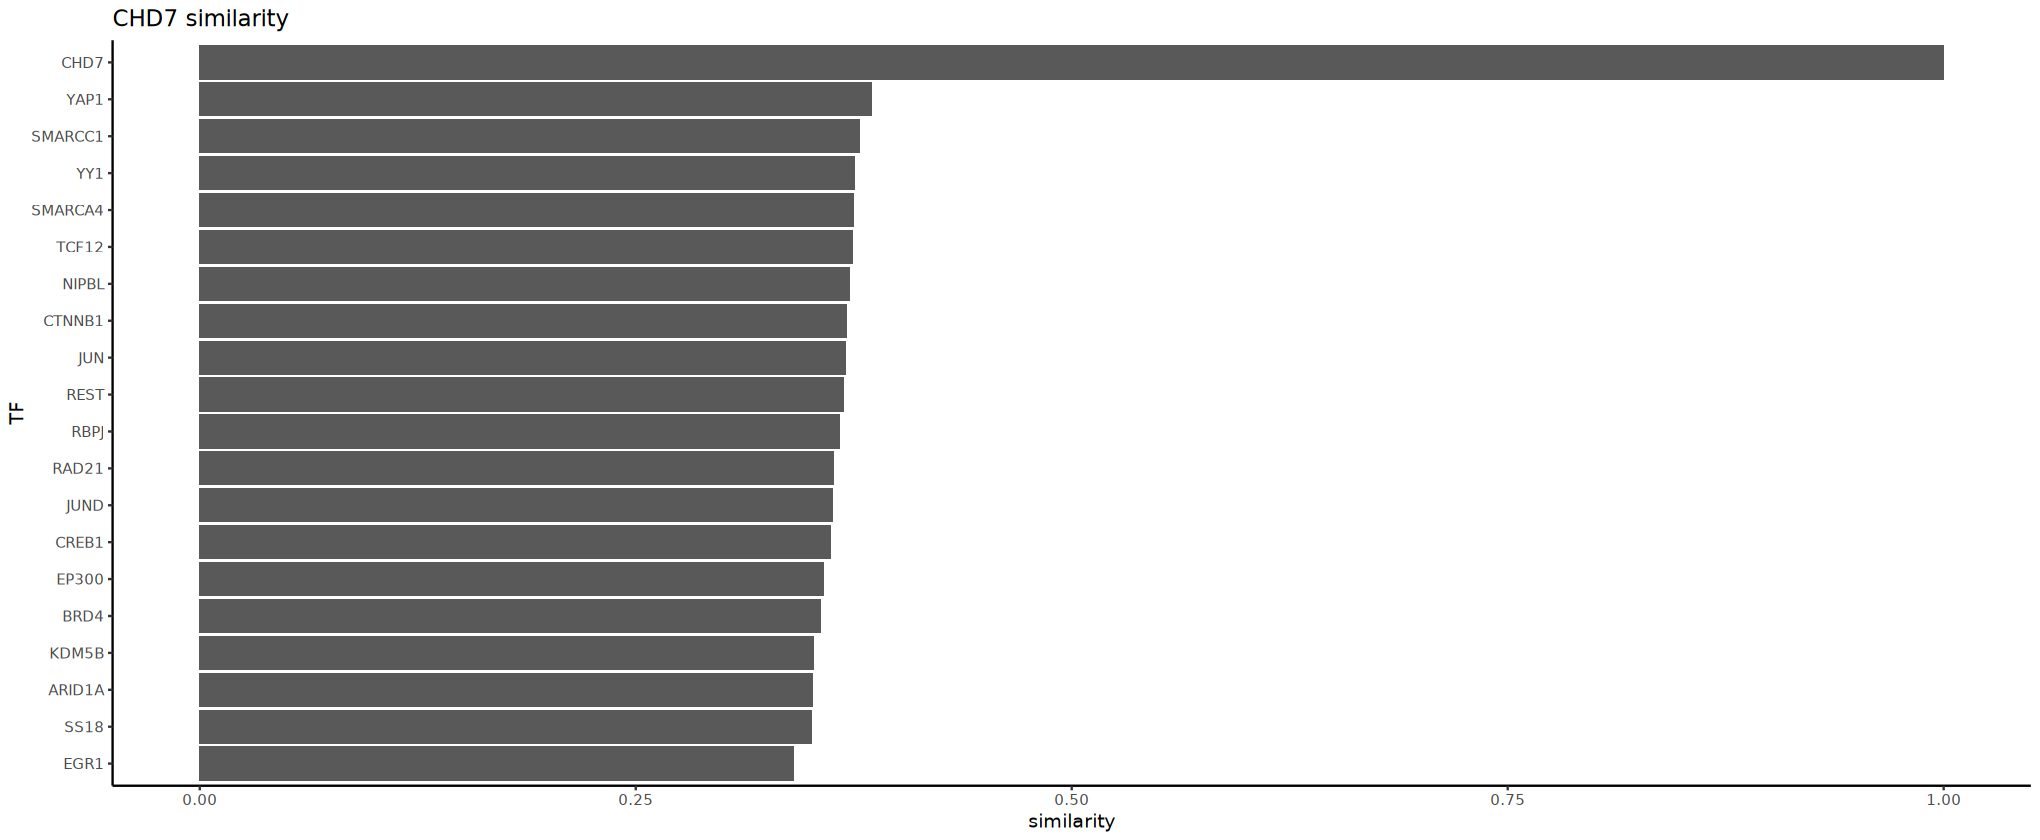

In [228]:
diff_graph_filter <- subgraph.edges(diff_graph, 
                                    E(diff_graph)[E(diff_graph)$weight>0], 
                                    del=TRUE)


# compute a similarity matrix of all TFs:

similarity_score <- epiregulon.extra::calculateJaccardSimilarity(diff_graph_filter)

# Focus on CHD7:
similarity_score_CHD7 <- similarity_score[, "CHD7"]
similarity_df <- data.frame(similarity = head(sort(similarity_score_CHD7, 
                                                   decreasing = TRUE),20),
                            TF = names(head(sort(similarity_score_CHD7,
                                                 decreasing = TRUE),20)))

similarity_df$TF <- factor(similarity_df$TF, 
                           levels = rev(unique(similarity_df$TF)))

# plot top TFs most similar to SPI1
topTFplot <- ggplot(similarity_df, aes(x=TF, y=similarity)) +
  geom_bar(stat="identity") +
  coord_flip() +
  ggtitle("CHD7 similarity") +
  theme_classic()

print(topTFplot)

In [230]:
ls() |> print()

 [1] "C2"                     "GeneExpressionMatrix"   "H"                     
 [4] "PeakMatrix"             "Pericytes_network"      "diff_graph"            
 [7] "diff_graph_filter"      "diff_matrix"            "diff_matrix_df"        
[10] "ec_network"             "enrichresults"          "grl"                   
[13] "gs"                     "gs.list"                "markers"               
[16] "markers.sig"            "my_epiregulon_lib"      "my_theme"              
[19] "overlap"                "p1"                     "p2g"                   
[22] "p_matrix"               "pericytes_network"      "permute_matrix"        
[25] "plot_1"                 "pruned.regulon"         "rank_table"            
[28] "regulon"                "regulon.w"              "score.combine"         
[31] "similarity_df"          "similarity_score"       "similarity_score_CHD7" 
[34] "similarity_score_SOX17" "tfs_interest"           "topTFplot"             


In [232]:
regulon.w

DataFrame with 1726147 rows and 14 columns
          idxATAC         chr     start       end    idxRNA      target
        <integer> <character> <integer> <integer> <integer> <character>
1             500       chr10 102452780 102453181      2743        SUFU
2            3296       chr10  11685819  11686220      2195      USP6NL
3            8072       chr10  16811761  16812162      2229        RSU1
4            8249       chr10  17578642  17579043      2233     ST8SIA6
5            9035       chr10  22615883  22616284      2254     PIP4K2A
...           ...         ...       ...       ...       ...         ...
1726143    389356        chr9  62801072  62801473     19314   LINC01410
1726144    390340        chr9  73152451  73152852     19352       ANXA1
1726145    396276        chrX 115615099 115615500     20412        PLS3
1726146    396458        chrX 118839301 118839702     20419     IL13RA1
1726147    402458        chrX  47582133  47582534     20071       TIMP1
         distance    

In [234]:
regulon.w$weight |> head()

all,endothelial_cells,immune_cells,neurons,oligodendrocyte_precursors,pericytes,radial_and_glioblast,vascular_leptomeningeal_cells_vlmc,vascular_smooth_muscle_cells,ventricular_zone_progenitor_cells_vz_prog
0.2562854,0.06412986,0.26337473,0.021733045,-0.02724400,0.042707651,0.06136623,-0.02104606,0.083159154,0.05570260
0.3353917,0.37074786,0.31081214,0.142025694,0.12463826,0.271318969,0.13586397,0.11667321,-0.007622979,0.00000000
0.2287160,0.04413277,0.03497056,0.001051567,0.11633283,0.224921386,0.04154337,-0.00429633,0.265068637,0.25243908
0.5490187,0.40290026,0.18065818,0.042592055,-0.02143816,0.429374891,0.06387169,0.09043799,0.168531738,0.00000000
0.3300173,0.06965166,0.31690625,0.115574375,0.15330743,0.007558371,0.18792178,0.08233812,0.053242505,0.08941168
0.4329349,0.50932826,0.19568721,0.012710164,0.22772210,0.176549855,0.07759464,0.32022317,0.306097661,0.11001306


In [235]:
regulon.w |> saveRDS(here::here('r_objects', 'regulon_weighted_by_celltypes.RDS'))

In [236]:
regulon.w$weight |> class()

[1] "matrix" "array"

In [237]:
regulon.w |> class()

[1] "DFrame"
attr(,"package")
[1] "S4Vectors"

In [238]:
regulon.w$qval |> head()

all,endothelial_cells,immune_cells,neurons,oligodendrocyte_precursors,pericytes,radial_and_glioblast,vascular_leptomeningeal_cells_vlmc,vascular_smooth_muscle_cells,ventricular_zone_progenitor_cells_vz_prog
9.960063e-08,1,1.000000e+00,1,1,1,1.00000000,1,1,1
1.591823e-05,1,1.000000e+00,1,1,1,1.00000000,1,1,1
1.512874e-01,1,1.000000e+00,1,1,1,1.00000000,1,1,1
6.340692e-172,1,5.494045e-13,1,1,1,0.03196328,1,1,1
1.380170e-12,1,1.000000e+00,1,1,1,1.00000000,1,1,1
2.233668e-13,1,1.000000e+00,1,1,1,1.00000000,1,1,1


In [239]:
table(regulon.w$qval[,'endothelial_cells'] < 0.05)


  FALSE    TRUE 
1658746   67401 

In [242]:
regulon.w$weight |> summary() |> print()

      all          endothelial_cells   immune_cells         neurons         
 Min.   :-0.4964   Min.   :-0.38282   Min.   :-0.19237   Min.   :-0.349021  
 1st Qu.: 0.1842   1st Qu.: 0.01090   1st Qu.: 0.08299   1st Qu.: 0.005305  
 Median : 0.2621   Median : 0.08884   Median : 0.15939   Median : 0.049840  
 Mean   : 0.2665   Mean   : 0.11219   Mean   : 0.16790   Mean   : 0.066752  
 3rd Qu.: 0.3430   3rd Qu.: 0.18651   3rd Qu.: 0.24654   3rd Qu.: 0.101759  
 Max.   : 0.9915   Max.   : 0.99902   Max.   : 0.99829   Max.   : 0.999483  
 oligodendrocyte_precursors   pericytes        radial_and_glioblast
 Min.   :-0.47487           Min.   :-0.31841   Min.   :-0.36742    
 1st Qu.: 0.02589           1st Qu.: 0.03005   1st Qu.: 0.02006    
 Median : 0.09235           Median : 0.09741   Median : 0.06633    
 Mean   : 0.11051           Mean   : 0.12219   Mean   : 0.08728    
 3rd Qu.: 0.17333           3rd Qu.: 0.20028   3rd Qu.: 0.13255    
 Max.   : 0.99889           Max.   : 0.99923   Max.  

In [244]:
# I will save the gexp and peak matrices as rds objects:

ls()

[1] "C2"                     "GeneExpressionMatrix"   "H"                     
 [4] "PeakMatrix"             "Pericytes_network"      "diff_graph"            
 [7] "diff_graph_filter"      "diff_matrix"            "diff_matrix_df"        
[10] "ec_network"             "enrichresults"          "grl"                   
[13] "gs"                     "gs.list"                "markers"               
[16] "markers.sig"            "my_epiregulon_lib"      "my_theme"              
[19] "overlap"                "p1"                     "p2g"                   
[22] "p_matrix"               "pericytes_network"      "permute_matrix"        
[25] "plot_1"                 "pruned.regulon"         "rank_table"            
[28] "regulon"                "regulon.w"              "score.combine"         
[31] "similarity_df"          "similarity_score"       "similarity_score_CHD7" 
[34] "similarity_score_SOX17" "tfs_interest"           "topTFplot"

In [246]:
PeakMatrix |> saveRDS(here::here('r_objects', 'PeakMatrix_used_for_epiregulon.RDS'))

In [247]:
GeneExpressionMatrix |> saveRDS(here::here('r_objects', 'GeneExpressionMatrix_used_for_epiregulon.RDS'))

In [248]:
# Next, I will extract the eGRNs for specific cell types.

sessionInfo()

R version 4.4.2 (2024-10-31)
Platform: x86_64-unknown-linux-gnu
Running under: Red Hat Enterprise Linux 9.4 (Plow)

Matrix products: default
BLAS/LAPACK: /gnu/store/mj1kw87qd3m1q7r4844adkn5hifx8k6a-openblas-0.3.20/lib/libopenblasp-r0.3.20.so;  LAPACK version 3.9.0

locale:
 [1] LC_CTYPE=C          LC_NUMERIC=C        LC_TIME=C          
 [4] LC_COLLATE=C        LC_MONETARY=C       LC_MESSAGES=C.UTF-8
 [7] LC_PAPER=C          LC_NAME=C           LC_ADDRESS=C       
[10] LC_TELEPHONE=C      LC_MEASUREMENT=C    LC_IDENTIFICATION=C

time zone: Europe/Berlin
tzcode source: system (glibc)

attached base packages:
[1] stats4    stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] igraph_2.1.4                ggplot2_3.5.1              
 [3] org.Hs.eg.db_3.19.1         AnnotationDbi_1.66.0       
 [5] msigdbr_7.5.1               scMultiome_1.4.2           
 [7] MultiAssayExperiment_1.30.3 ExperimentHub_2.12.0       
 [9] AnnotationHub_3.12.0  